# Libraries

In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import *
from data_fit import *
from data_plot import *
import scipy
pi = np.pi 

In [4]:
def Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s):
    return Polydisperse_spheres(x, scale, Ravg, p, bkg)+log_normal_peak(x, I0, q0, s)

def Spheres_norm(x, scale, Ravg, p, bkg, I0, q0, s):
    return Polydisperse_spheres(x, scale, Ravg, p, bkg)+normal_peak(x, I0, q0, s)

def Monodisperse_spheres(x, scale, R, SLD_sphere, SLD_solvent, bkg): #Scattering of a single homogeneous sphere
    ro = SLD_sphere - SLD_solvent
    V = 4 * np.pi * R**3
    return (scale / V) * (3*V*ro*(np.sin(x*R)-x*R*np.cos(x*R))/(x*R)**3)**2 + bkg
    
def Gaussian(R, sigma, Ravg):
    return 1/(sigma * np.sqrt(2*np.pi)) * np.exp((-1/(2*sigma**2)) * (R-Ravg)**2)

def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global counter 
    global sigma
    sigma = p*Ravg
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2) 
        Iq.append(scale* scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    return Iq

def log_normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))

def normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(q - q0)**2 / (2 * s**2))

array([6.93804417e-05, 1.80130308e+01, 1.59986888e-01, 1.07954548e+01])

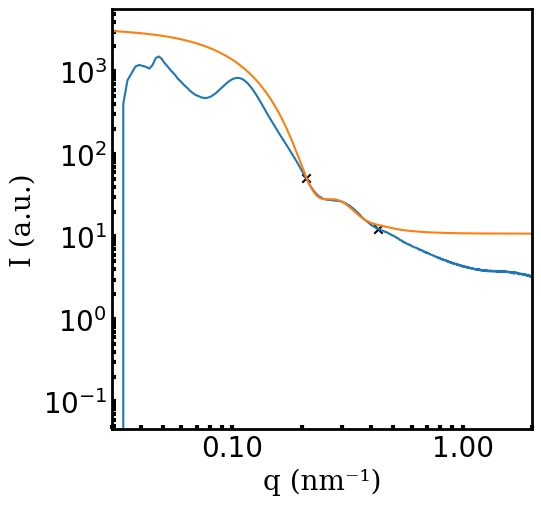

In [5]:
experiment_path = r'E:\PEG_PNIPAM crystallization\SC5711\PEG_PNIPAM_lastsynthesis\PEG_PNIPAM_lastsynthesis_PEG_PNIPAM_576_12_90C'
df_new576_6 = BM26_experiment(experiment_path)
q, I = df_new576_6.get_1d_SAXS()

SAXS_plot(6,6 )
plt.plot(q, I)

l = 145
r = 300
plt.scatter(q[l], I[l], marker='x', color='black')
plt.scatter(q[r], I[r], marker='x', color='black')

p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[7.33855464e-05, 1.80958210e+01, 1.56985830e-01, 0.1])

plt.plot(q, Polydisperse_spheres(q, *[6.93804417e-05, 1.80130308e+01, 1.59986888e-01, 1.07954548e+01]))
plt.xlim(0.03, 2)
p

In [75]:
Exp292_6_0C.

# Data

### 292_6

In [7]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_0C"
Exp292_6_0C = BM26_experiment(experiment_path)
Info292_6_0C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_0.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_5C"
Exp292_6_5C = BM26_experiment(experiment_path)
Info292_6_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_10C"
Exp292_6_10C = BM26_experiment(experiment_path)
Info292_6_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_10C.csv")

### 292_12

In [8]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_10C"
Exp292_12_10C = BM26_experiment(experiment_path)
Info292_12_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_15C"
Exp292_12_15C = BM26_experiment(experiment_path)
Info292_12_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_15C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_17_5C"
Exp292_12_17_5C = BM26_experiment(experiment_path)
Info292_12_17_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_17_5C.csv")

### 292_24

In [9]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_10C"
Exp292_24_10C = BM26_experiment(experiment_path)
Info292_24_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_15C"
Exp292_24_15C = BM26_experiment(experiment_path)
Info292_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_15C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_20C"
Exp292_24_20C = BM26_experiment(experiment_path)
Info292_24_20C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_20C.csv")

### 576_6

In [10]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_0C"
Exp576_6_0C = BM26_experiment(experiment_path)
Info576_6_0C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_0C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_10C"
Exp576_6_10C = BM26_experiment(experiment_path)
Info576_6_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_15C"
Exp576_6_15C = BM26_experiment(experiment_path)
Info576_6_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_15C.csv")

### 576_12

In [11]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_5C"
Exp576_12_5C = BM26_experiment(experiment_path)
Info576_12_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_10C"
Exp576_12_10C = BM26_experiment(experiment_path)
Info576_12_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_15C"
Exp576_12_15C = BM26_experiment(experiment_path)
Info576_12_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_15C.csv")

### 576-24

In [12]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_576_24_Cryst_at_15C_bis"
Exp576_24_15C = BM26_experiment(experiment_path)
Info576_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_15C_bis.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_5C"
Exp576_24_5C = BM26_experiment(experiment_path)
Info576_24_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_10C"
Exp576_24_10C = BM26_experiment(experiment_path)
Info576_24_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_20C"
Exp576_24_20C = BM26_experiment(experiment_path)
Info576_24_20C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_20C.csv")

### 888_24

In [13]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_888_24_Cryst_at_15C"
Exp888_24_15C = BM26_experiment(experiment_path)
Info888_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_888_24_Cryst_at_15C.csv")


# Functions

In [74]:
def Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s):
    return Polydisperse_spheres(x, scale, Ravg, p, bkg)+log_normal_peak(x, I0, q0, s)

def Spheres_norm(x, scale, Ravg, p, bkg, I0, q0, s):
    return Polydisperse_spheres(x, scale, Ravg, p, bkg)+normal_peak(x, I0, q0, s)

def Monodisperse_spheres(x, scale, R, SLD_sphere, SLD_solvent, bkg): #Scattering of a single homogeneous sphere
    ro = SLD_sphere - SLD_solvent
    V = 4 * np.pi * R**3
    return (scale / V) * (3*V*ro*(np.sin(x*R)-x*R*np.cos(x*R))/(x*R)**3)**2 + bkg
    
def Gaussian(R, sigma, Ravg):
    return 1/(sigma * np.sqrt(2*np.pi)) * np.exp((-1/(2*sigma**2)) * (R-Ravg)**2)

def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global counter 
    global sigma
    sigma = p*Ravg
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2) 
        Iq.append(scale* scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    return Iq

def log_normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))

def normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(q - q0)**2 / (2 * s**2))

def Lognorm_power(q, I0, q0, s, I_p, p):
    return log_normal_peak(q, I0, q0, s) + I_p * q ** -p

In [15]:
def sigmoid(x, A, alpha, m):
  """
  Calculates the sigmoid function for a given input x.
  """
  return A / (1 + np.exp(-alpha*(x-m)))

# Analysis

### 292_6

##### data

In [16]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_0C"
Exp292_6_0C = BM26_experiment(experiment_path)
Info292_6_0C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_0.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_5C"
Exp292_6_5C = BM26_experiment(experiment_path)
Info292_6_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_10C"
Exp292_6_10C = BM26_experiment(experiment_path)
Info292_6_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_10C.csv")

#### 0C

0.636889289743589


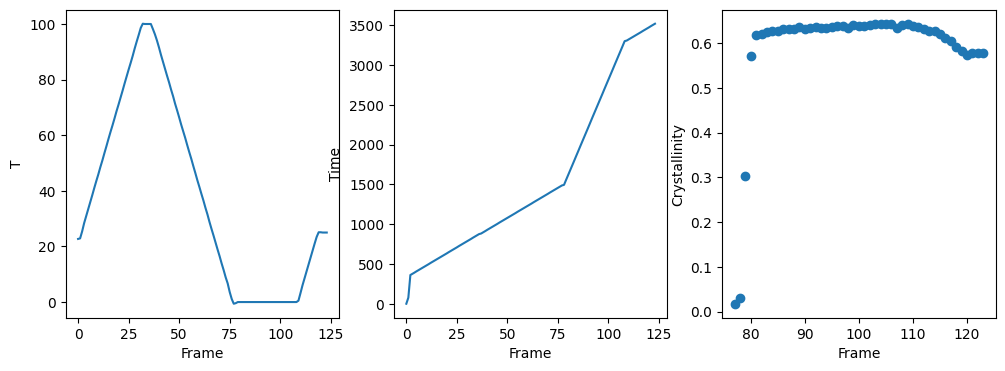

In [17]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info292_6_0C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][85:110]))

(0.008, 1300.0)

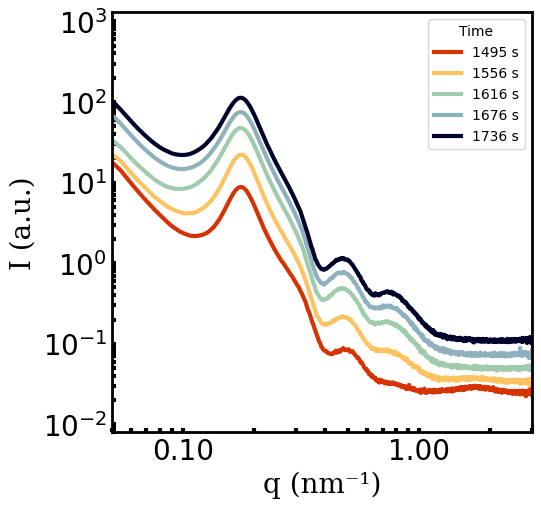

In [18]:
SAXS_plot(6,6)

Data = Exp292_6_0C
lnwdth = 3
k = 1.5
times = [78, 79, 80, 81, 82]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Data.get_1d_SAXS(times[0])
plt.plot(q, I, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Data.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Data.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Data.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Data.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(0.05, 3)
plt.ylim(0.8e-2, 13e2)

In [19]:
Spheres_log_norm

<function __main__.Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s)>

C:\Users\LabPC\AppData\Local\Temp\ipykernel_13196\650693639.py:27: RuntimeWarning: invalid value encountered in log
  return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))


array([1.36448232e-05, 1.14167559e+01, 1.18357112e-01, 2.18272795e-02,
       3.68738099e-02, 7.62843864e-01, 1.75849305e-01])

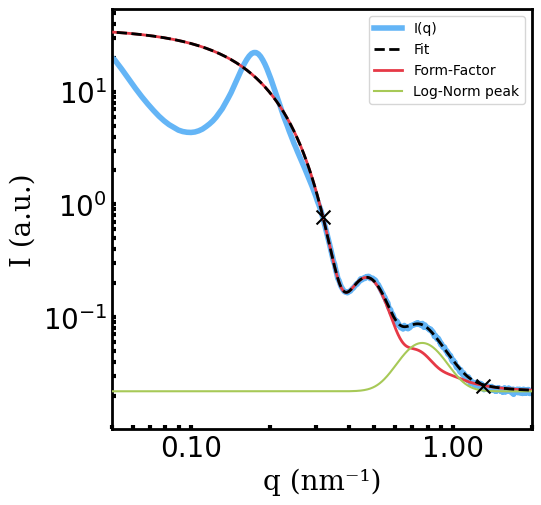

In [20]:
SAXS_plot(6,6)

q, I = Data.get_1d_SAXS(82)
plt.plot(q, I, linewidth=4, color='#64b5f6', label='I(q)')

l = 90
r = 370
plt.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
plt.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 11, 0.12, 8.91806121e-03,  5.32180981e-03, 0.8, 0.2 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label = 'Form-Factor', linewidth=2)
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')
plt.legend()
plt.xlim(0.05, 2)
p

In [21]:
2*pi/0.175

35.90391604102621

In [22]:
2*p[1]

np.float64(22.833511827224864)

In [23]:
2*pi/p[5]

np.float64(8.236528602827333)

#### 5C

0.6241113145974102


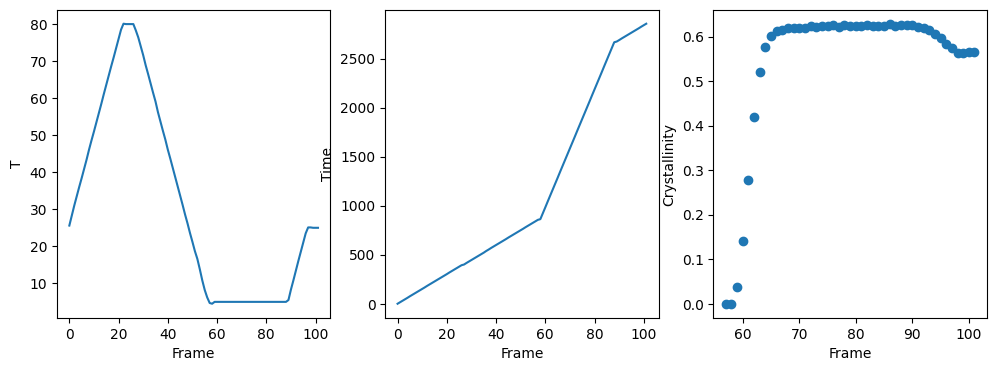

In [24]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info292_6_5C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][70:90]))

(0.008, 1300.0)

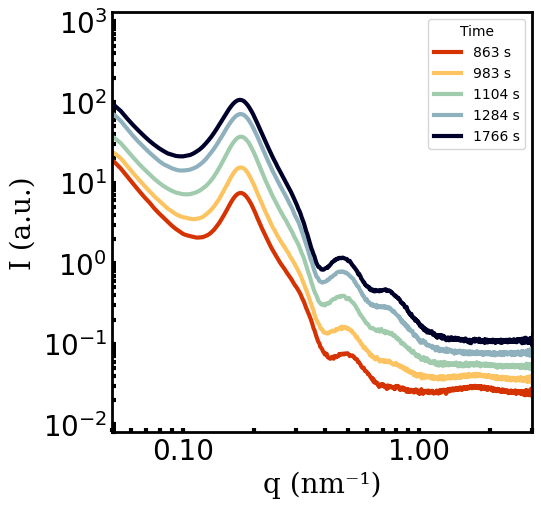

In [20]:
SAXS_plot(6,6)

Data = Exp292_6_5C
lnwdth = 3
k = 1.5
times = [58, 60, 62, 65, 73]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Data.get_1d_SAXS(times[0])
plt.plot(q, I, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Data.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Data.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Data.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Data.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(0.05, 3)
plt.ylim(0.8e-2, 13e2)

array([1.33334535e-05, 1.15050491e+01, 1.19127762e-01, 2.02815305e-02,
       4.05488594e-02, 7.13532042e-01, 1.86307231e-01])

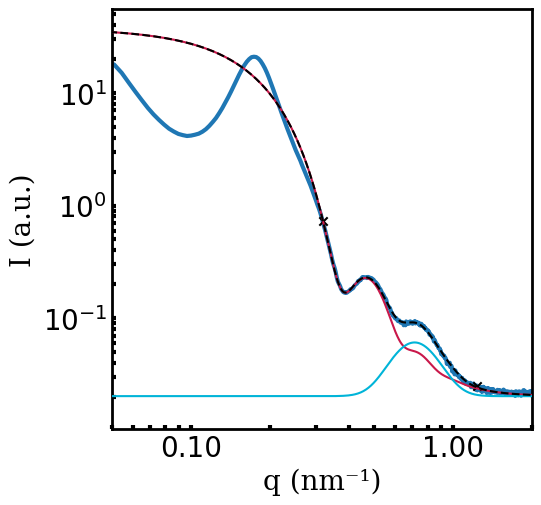

In [21]:
SAXS_plot(6,6)

q, I = Data.get_1d_SAXS(72)
plt.plot(q, I, linewidth=3)

l = 90
r = 350
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1.35532939e-05, 1.14792157e+01, 1.19485238e-01, 2.01036077e-02,
       3.57352762e-02, 7.06913625e-01, 1.86266722e-01 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [22]:
2*p[1]

np.float64(23.010098253577578)

In [23]:
2*pi/p[5]

np.float64(8.805750734403455)

#### 10C

0.5938321166635357


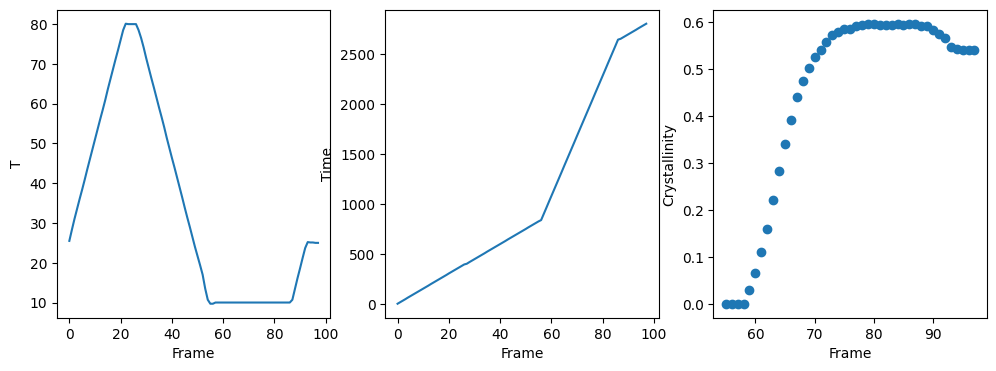

In [24]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info292_6_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][77:88]))

(0.008, 1300.0)

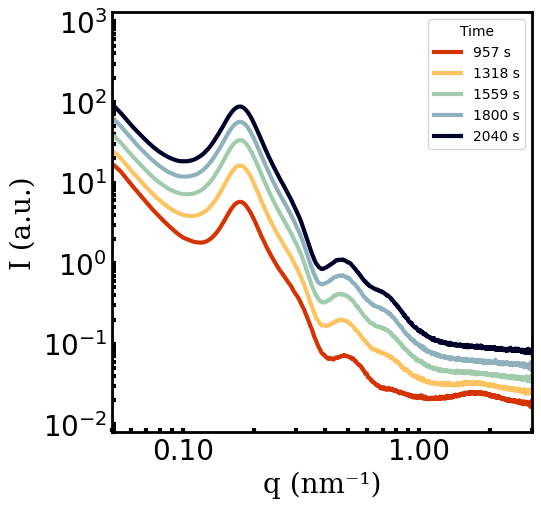

In [25]:
SAXS_plot(6,6)

Data = Exp292_6_10C
lnwdth = 3
k = 1.5
times = [58, 64, 68, 72, 76]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Data.get_1d_SAXS(times[0])
plt.plot(q, I, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Data.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Data.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Data.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Data.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(0.05, 3)
plt.ylim(0.8e-2, 13e2)

array([1.20328690e-05, 1.15301150e+01, 1.25910556e-01, 1.72093103e-02,
       5.36386782e-02, 6.41158930e-01, 2.12653396e-01])

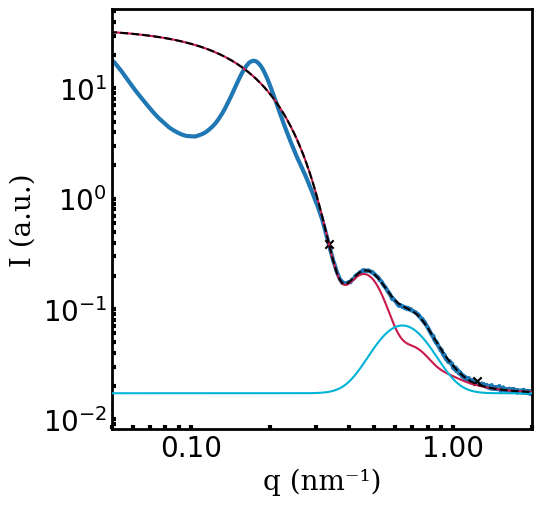

In [26]:
SAXS_plot(6,6)

q, I = Exp292_6_10C.get_1d_SAXS(82)
plt.plot(q, I, linewidth=3)

l = 95
r = 350
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1.35532939e-05, 1.14792157e+01, 1.19485238e-01, 2.01036077e-02,
       3.57352762e-02, 7.06913625e-01, 1.86266722e-01 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [27]:
2*p[1]

np.float64(23.06023001626369)

In [28]:
2*pi/p[5]

np.float64(9.799731411664046)

### 292_12

#### data

In [29]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_10C"
Exp292_12_10C = BM26_experiment(experiment_path)
Info292_12_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_15C"
Exp292_12_15C = BM26_experiment(experiment_path)
Info292_12_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_15C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_17_5C"
Exp292_12_17_5C = BM26_experiment(experiment_path)
Info292_12_17_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_17_5C.csv")

#### 10C

0.5932836365332166


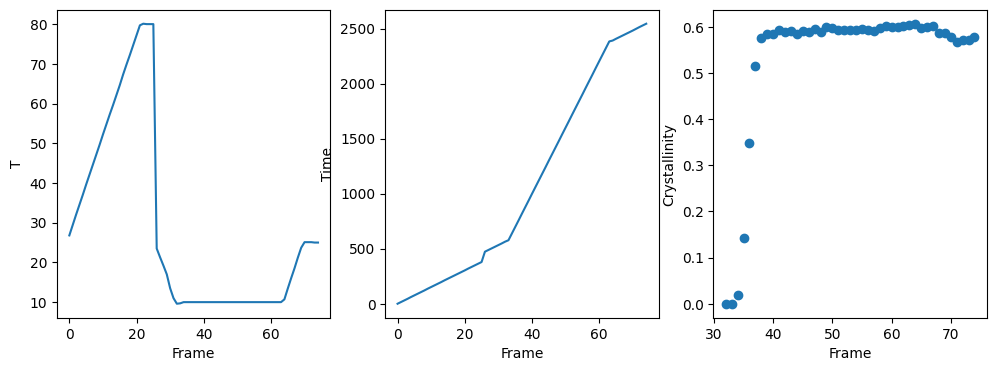

In [54]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info292_12_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][40:60]))

(0.008, 1300.0)

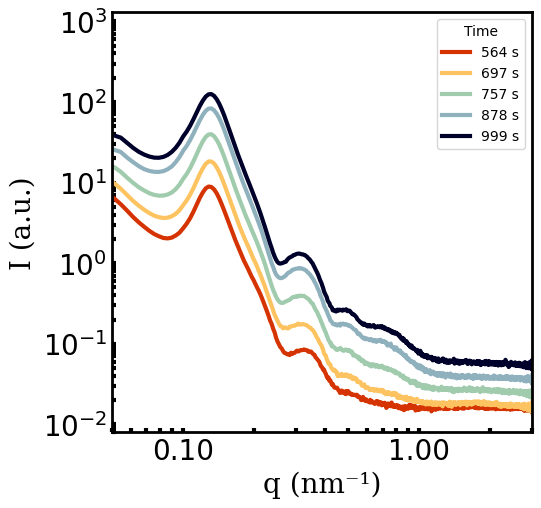

In [55]:
SAXS_plot(6,6)

Data = Exp292_12_10C
lnwdth = 3
k = 1.5
times = [32, 35, 36, 38, 40]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Data.get_1d_SAXS(times[0])
plt.plot(q, I, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Data.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Data.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Data.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Data.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(0.05, 3)
plt.ylim(0.8e-2, 13e2)

array([1.51567190e-06, 1.70821404e+01, 1.20984099e-01, 1.09414925e-02,
       1.18025331e-02, 7.16484162e-01, 1.95792849e-01])

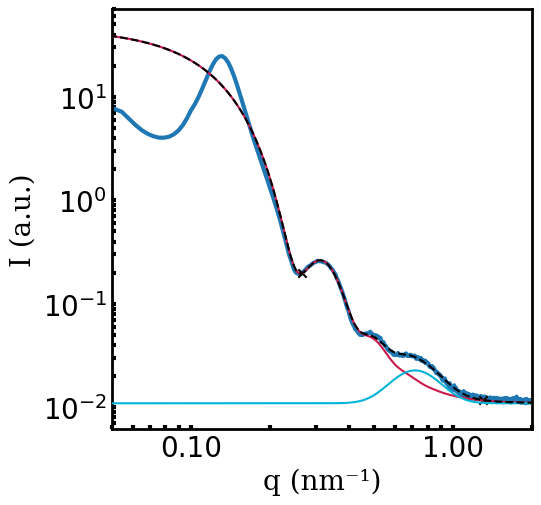

In [56]:
SAXS_plot(6,6)

q, I = Exp292_12_10C.get_1d_SAXS(50)
plt.plot(q, I, linewidth=3)

l = 75
r = 370
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1.48800689e-06, 1.71461996e+01, 1.18588026e-01, 1.13931544e-02,
       1.14996878e-02, 7.13869824e-01, 1.90167112e-01 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [57]:
2*p[1]

np.float64(34.16428085085164)

In [58]:
p[5]

np.float64(0.7164841619987306)

In [59]:
2*pi/p[5]

np.float64(8.76946852481956)

#### 15C

0.5578550009437141


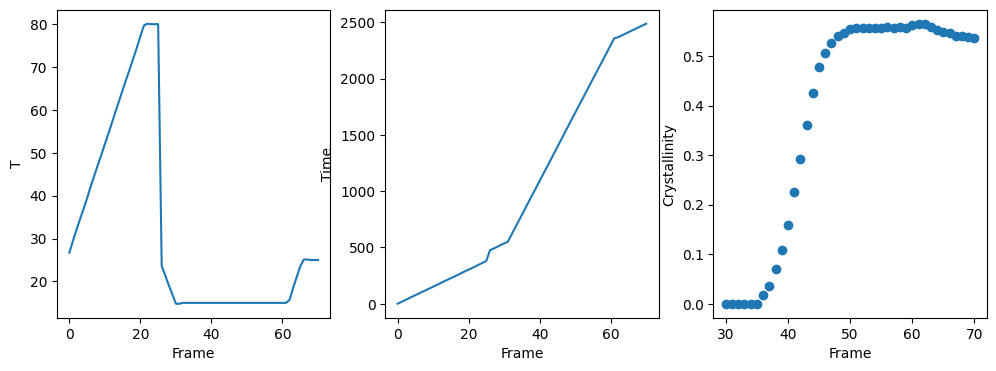

In [49]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info292_12_15C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][55:60]))

(0.008, 1300.0)

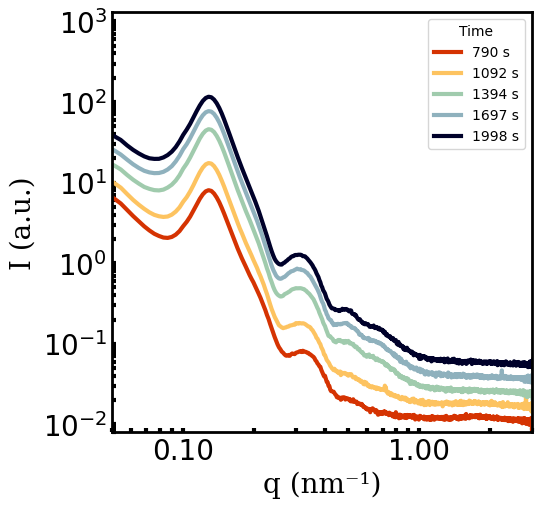

In [50]:
SAXS_plot(6,6)

Data = Exp292_12_15C
lnwdth = 3
k = 1.5
times = [35, 40, 45, 50, 55]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Data.get_1d_SAXS(times[0])
plt.plot(q, I, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Data.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Data.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Data.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Data.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(0.05, 3)
plt.ylim(0.8e-2, 13e2)

array([1.40802571e-06, 1.72059052e+01, 1.20279522e-01, 1.14484924e-02,
       9.78883731e-03, 6.29429600e-01, 1.98642863e-01])

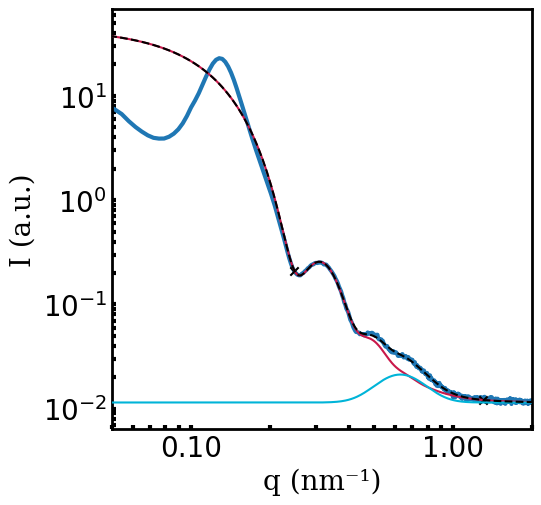

In [51]:
SAXS_plot(6,6)

q, I = Exp292_12_15C.get_1d_SAXS(55)
plt.plot(q, I, linewidth=3)

l = 70
r = 370
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1.48800689e-06, 1.71461996e+01, 1.18588026e-01, 1.13931544e-02,
       1.14996878e-02, 7.13869824e-01, 1.90167112e-01 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [52]:
2*p[1]

np.float64(34.41181039489101)

In [53]:
2*pi/p[5]

np.float64(9.982347995108302)

#### 17.5 C

0.5434051862124036


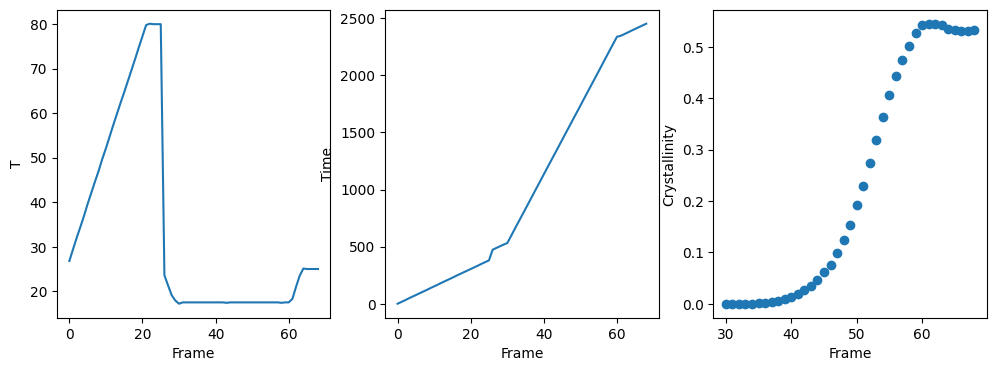

In [123]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info292_12_17_5C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][60:62]))

Чтение SAXS файла 30: PEG_PNIPAM_292_12_Cryst_at_17_5C_SAXS_0030.dat
Чтение SAXS файла 40: PEG_PNIPAM_292_12_Cryst_at_17_5C_SAXS_0040.dat
Чтение SAXS файла 50: PEG_PNIPAM_292_12_Cryst_at_17_5C_SAXS_0050.dat
Чтение SAXS файла 55: PEG_PNIPAM_292_12_Cryst_at_17_5C_SAXS_0055.dat
Чтение SAXS файла 62: PEG_PNIPAM_292_12_Cryst_at_17_5C_SAXS_0062.dat


(0.008, 1300.0)

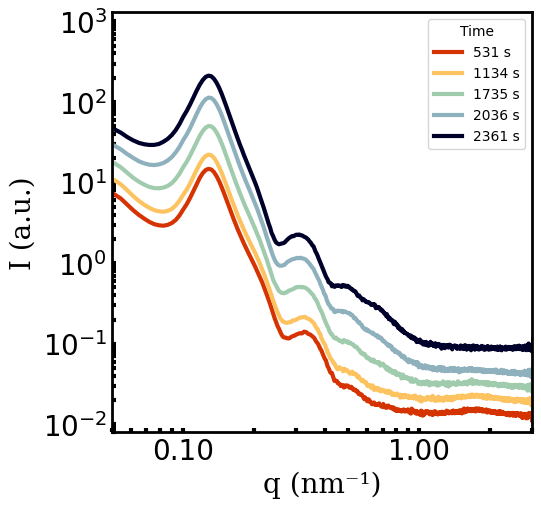

In [125]:
SAXS_plot(6,6)

Data = Exp292_12_17_5C
lnwdth = 3
k = 1.5
times = [30, 40, 50, 55, 62]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Data.get_1d_SAXS(times[0])
plt.plot(q, I, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Data.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Data.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Data.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Data.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(0.05, 3)
plt.ylim(0.8e-2, 13e2)

Чтение SAXS файла 62: PEG_PNIPAM_292_12_Cryst_at_17_5C_SAXS_0062.dat


array([2.47169209e-06, 1.72539483e+01, 1.20659156e-01, 1.68015230e-02,
       2.59483694e-02, 5.67262630e-01, 2.37634026e-01])

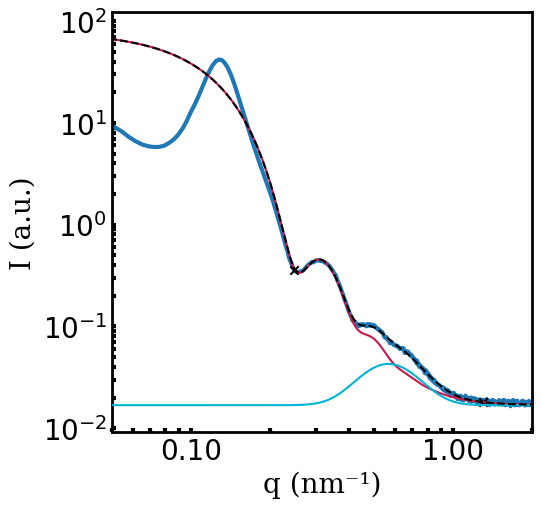

In [126]:
SAXS_plot(6,6)

q, I = Exp292_12_17_5C.get_1d_SAXS(62)
plt.plot(q, I, linewidth=3)

l = 70
r = 370
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1.48800689e-06, 1.71461996e+01, 1.18588026e-01, 1.13931544e-02,
       1.14996878e-02, 7.13869824e-01, 1.90167112e-01 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [127]:
2*p[1]

np.float64(34.50789666835381)

In [129]:
2*pi/p[5]

np.float64(11.07632509225534)

### 292_24

#### data

In [25]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_10C"
Exp292_24_10C = BM26_experiment(experiment_path)
Info292_24_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_15C"
Exp292_24_15C = BM26_experiment(experiment_path)
Info292_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_15C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_20C"
Exp292_24_20C = BM26_experiment(experiment_path)
Info292_24_20C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_20C.csv")

#### 10C

0.5593783516133405


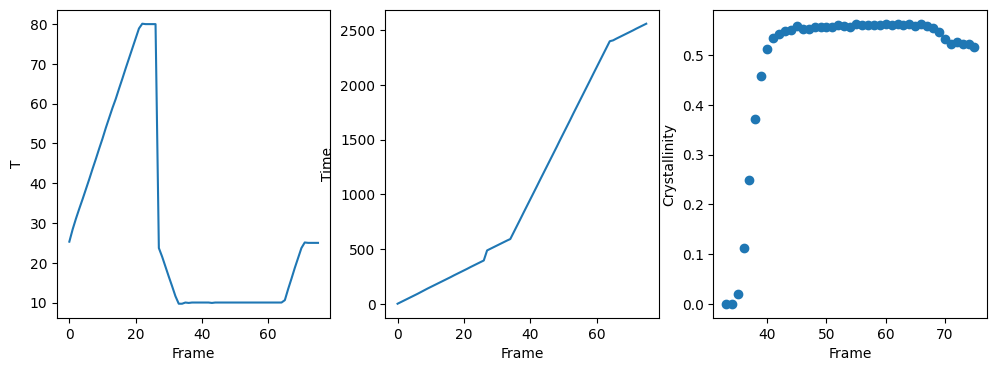

In [26]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info292_24_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][50:60]))

0.08142610868558159
0.08632889310480879


C:\Users\LabPC\AppData\Local\Temp\ipykernel_13196\1374028128.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(np.trapz((I1[l:r]-0.015)*q[l:r]**2, x=q[l:r]))
C:\Users\LabPC\AppData\Local\Temp\ipykernel_13196\1374028128.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(np.trapz((I2[l:r]-0.015)*q[l:r]**2, x=q[l:r]))


(0.008, 1300.0)

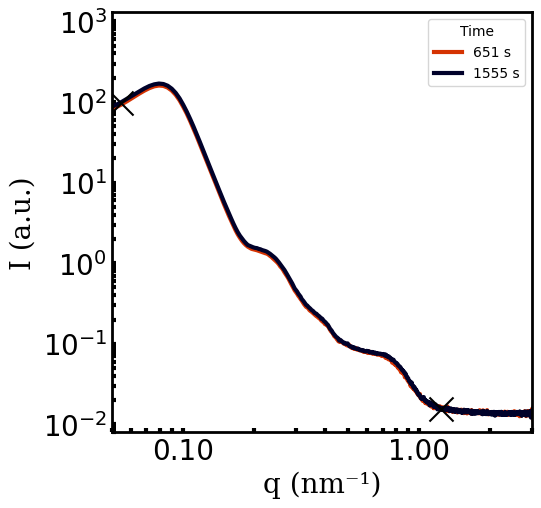

In [233]:
SAXS_plot(6,6)

Data = Exp292_24_10C
lnwdth = 3
k = 1.5
times = [35, 38, 42, 48, 50]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

k = 2.5
q, I1 = Data.get_1d_SAXS(40)
plt.plot(q, I1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')


# q, I = Data.get_1d_SAXS(times[1])
# plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

# q, I = Data.get_1d_SAXS(times[2])
# plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

# q, I = Data.get_1d_SAXS(times[3])
# plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I2 = Data.get_1d_SAXS(50)
plt.plot(q, I2 , linewidth=lnwdth, color='#00012A', label=f'{t5} s')

l = 15
r = 350
plt.scatter([q[l], q[r]], [I2[l], I2[r]], marker='x', zorder=10, color='black', s=300)

print(np.trapz((I1[l:r]-0.015)*q[l:r]**2, x=q[l:r]))
print(np.trapz((I2[l:r]-0.015)*q[l:r]**2, x=q[l:r]))

#plt.plot(q, I2-I1*k)

plt.legend(title='Time')
plt.xlim(0.05, 3)
plt.ylim(0.8e-2, 13e2)

In [234]:
Info292_24_10C

,Time,Temperature,Crystalinity,D 120,D 032,q1_Ampl
Unnamed: 0,,,,,,
0,0,25.3,NaN,NaN,NaN,NaN
1,15,28.4,NaN,NaN,NaN,NaN
2,30,31.1,NaN,NaN,NaN,NaN
3,45,33.6,NaN,NaN,NaN,NaN
4,60,36.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
71,2497,25.1,0.523154,23.773155,13.157688,NaN
72,2513,25.0,0.526618,23.950716,13.215291,NaN
73,2528,25.0,0.521387,23.970025,13.193514,NaN


(550.0, 2500.0)

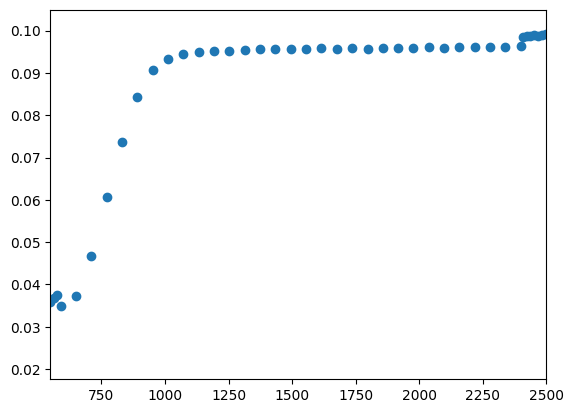

In [241]:
plt.scatter(Info292_24_10C['Time'], Inv)
#plt.scatter(Info292_24_10C['Crystalinity'], Inv)
#plt.semilogx()
#plt.semilogy()
plt.xlim(550, 2500)

C:\Users\LabPC\AppData\Local\Temp\ipykernel_13196\2589688827.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Inv.append(np.trapz(I[15:350]*q[15:350]**2, x=q[15:350]))


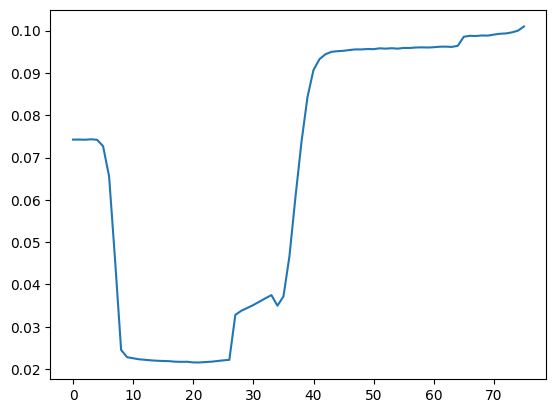

In [196]:
Inv = []

for i in range(76):
    q, I = Exp292_24_10C.get_1d_SAXS(i)

    Inv.append(np.trapz(I[15:350]*q[15:350]**2, x=q[15:350]))

plt.plot(range(76), Inv)
Inv = np.array(Inv)
#Inv -= Inv[31]
#Inv /= max(Inv)

In [219]:
rho1, rho2

(0.6035398230088496, 0.6545454545454544)

Text(0, 0.5, 'Invariant')

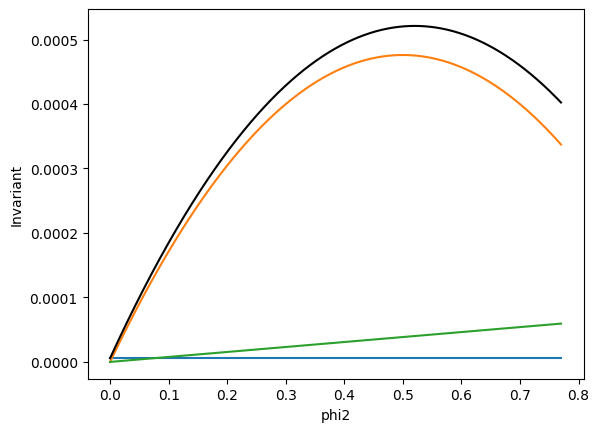

In [227]:
rho1 = 62 * 1.1 / 113 #* 7/8 + 1/8 * 24 * 1.12 / 44
rho2 = 24 * 1.2 / 44 
rho3 = 24 * 1.12 / 44 

phi1 = 0.12
phi2 = np.linspace(0, 0.77, 1000)
phi3 = 1 - phi1 - phi2

rho13 = rho1-rho3
rho12 = rho2-rho3
rho23 = rho2-rho3

Z1 = rho13**2 * phi1 * (1 - phi1)
Z2 = rho23 ** 2 * phi2 * (1 - phi2)
Z3 = - 2 * (rho1 - rho3) * (rho2 - rho3) * phi1 * phi2
Z = Z1 + Z2 + Z3
#plt.scatter(Info292_24_10C['Crystalinity'], Inv/ max(Inv))
plt.plot(phi2, Z1 * np.ones(1000))
plt.plot(phi2, Z2)
plt.plot(phi2, Z3)
plt.plot(phi2, Z, color='black')

plt.xlabel('phi2')
plt.ylabel('Invariant')


In [175]:
print(rho1)
print(rho2)

print(rho3)


68.2
29.759999999999998
26.880000000000003


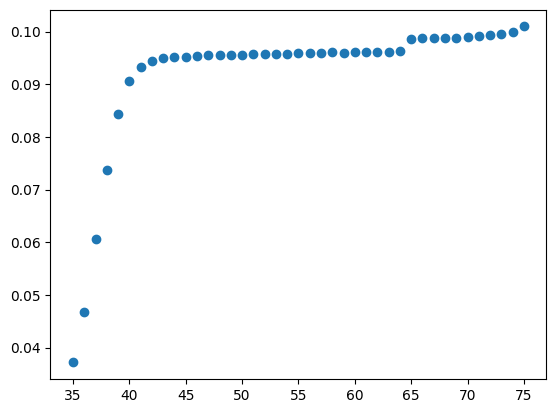

In [130]:

plt.scatter(range(76)[35:], Inv[35:])

array([1.47295990e-06, 2.23604489e+01, 1.71266908e-01, 4.45254960e-02])

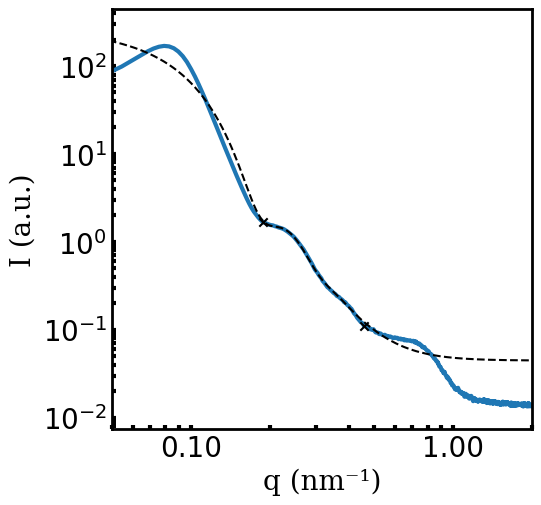

In [50]:
SAXS_plot(6,6)

q, I = Exp292_24_10C.get_1d_SAXS(50)
plt.plot(q, I, linewidth=3)

l = 130
r = 300
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')

p, cov = cutvr_fit(Lognorm_power, q[l:r], I[l:r])
plt.plot()

#p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[1.48800689e-06, 20, 1.18588026e-01, 1.13931544e-02 ])
#p, cov = curve_fit(Spheres_norm, q[l:r], I[l:r], p0=[1e-06, 2.17410137e+01, 0.12, 1.74640436e-02,  1.14996878e-1, 0.65, 1.90167112e-01 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
#plt.plot(q, Polydisperse_spheres(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
#plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')|
#plt.plot(q, normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [51]:
d2 = []
for i in range(28, 60):
    q, I = Exp292_24_10C.get_1d_SAXS(i)
    p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[1.47295990e-06, 2.23604489e+01, 1.71266908e-01, 4.45254960e-02 ])

    d2.append(2*p[1])
    

In [68]:
d2_np = np.array(d2)



In [70]:
a = [43.28989, 43.07832512795008, 43.20270249008861, 43.25633960326542, 43.1279751428226, 43.06185640437562, 43.16000530610641, 43.32720453393113, 43.87029841738402, 44.22466395790502, 44.50335245246358, 44.663618955634135, 44.653876929631956, 44.722246800477535, 44.737810479470724, 44.68522696740881, 44.71642829345015, 44.647992041475376, 44.674148991237665, 44.70398829483487, 44.69175541310044, 44.715527381976855, 44.72089762122286, 44.649704175954476, 44.700198377722735, 44.73379523496847, 44.66431659552171, 44.68231747116211, 44.67679730896704, 44.67000562499784, 44.64278267763738, 44.64701461872063]

In [71]:
a = np.array(a)
np.round(a, 3)

array([43.29 , 43.078, 43.203, 43.256, 43.128, 43.062, 43.16 , 43.327,
       43.87 , 44.225, 44.503, 44.664, 44.654, 44.722, 44.738, 44.685,
       44.716, 44.648, 44.674, 44.704, 44.692, 44.716, 44.721, 44.65 ,
       44.7  , 44.734, 44.664, 44.682, 44.677, 44.67 , 44.643, 44.647])

In [30]:
p[5]

np.float64(0.6597497361808056)

In [31]:
2*pi/p[5]

np.float64(9.523588965040023)

array([1.67247125e-06, 2.17045565e+01, 1.83372777e-01, 1.28293498e-02,
       4.46382071e-02, 6.43959254e-01, 2.67320333e-01])

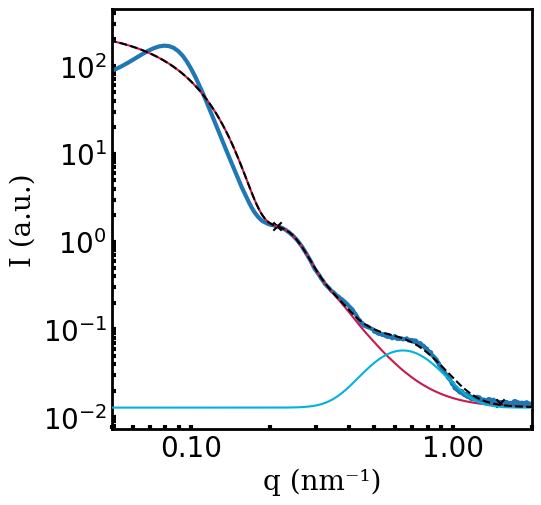

In [32]:
SAXS_plot(6,6)

q, I = Exp292_24_10C.get_1d_SAXS(60)
plt.plot(q, I, linewidth=3)

l = 60
r = 430
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[1.48800689e-06, 20, 1.18588026e-01, 1.13931544e-02 ])
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-06, 2.17410137e+01, 0.12, 1.74640436e-02,  1.14996878e-1, 0.65, 1.90167112e-01 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

[]

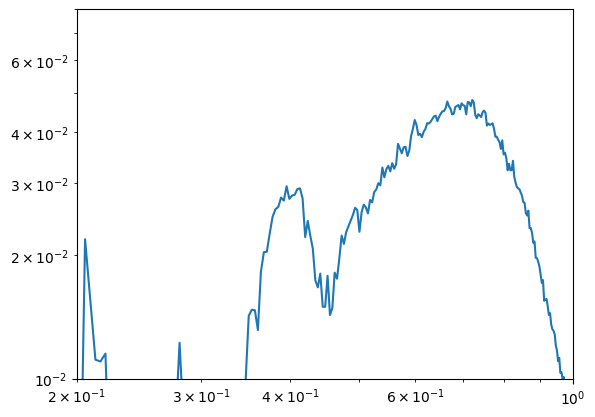

In [173]:
plt.plot(q, I- Polydisperse_spheres(q, *p[:4]))
plt.xlim(0.2, 1)
plt.ylim(1e-2, 0.08)
plt.semilogx()
plt.semilogy()

In [184]:
2*p[1]

np.float64(43.409113032171106)

In [145]:
2*pi/p[5]

79.53399123012134

In [169]:
p[5]

np.float64(0.6342505024313209)

#### 15C

0.512653924147704


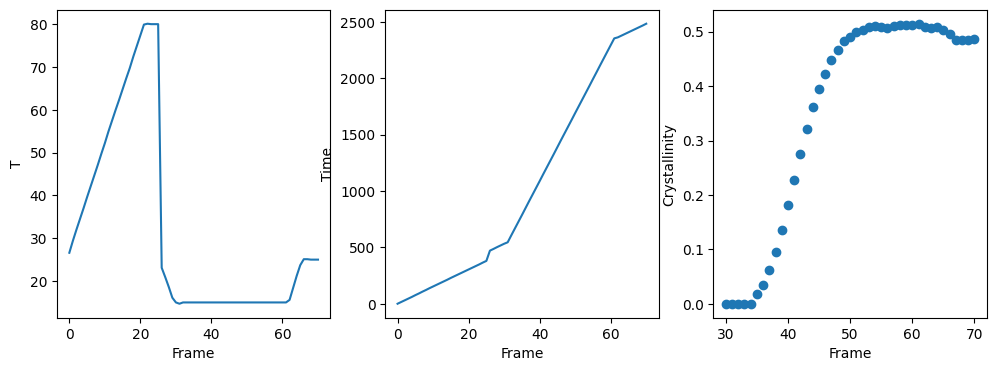

In [199]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info292_24_15C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][58:62]))

Чтение SAXS файла 60: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0060.dat


array([1.56433943e-06, 2.20587844e+01, 1.75114325e-01, 1.40746682e-02,
       5.88330332e-02, 5.95748262e-01, 1.78991125e-01])

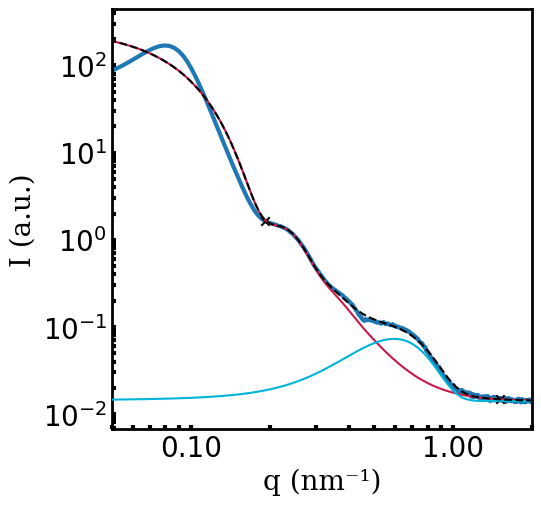

In [200]:
SAXS_plot(6,6)

q, I = Exp292_24_15C.get_1d_SAXS(60)
plt.plot(q, I, linewidth=3)

l = 54
r = 430
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[1.48800689e-06, 20, 1.18588026e-01, 1.13931544e-02 ])
p, cov = curve_fit(Spheres_norm, q[l:r], I[l:r], p0=[1e-06, 2.17410137e+01, 0.12, 1.74640436e-02,  1.14996878e-1, 0.65, 1.90167112e-01 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [201]:
2*p[1]

np.float64(44.11756877121296)

In [202]:
2*pi/p[5]

np.float64(10.546711943063771)

#### 20C

0.1117917831934208


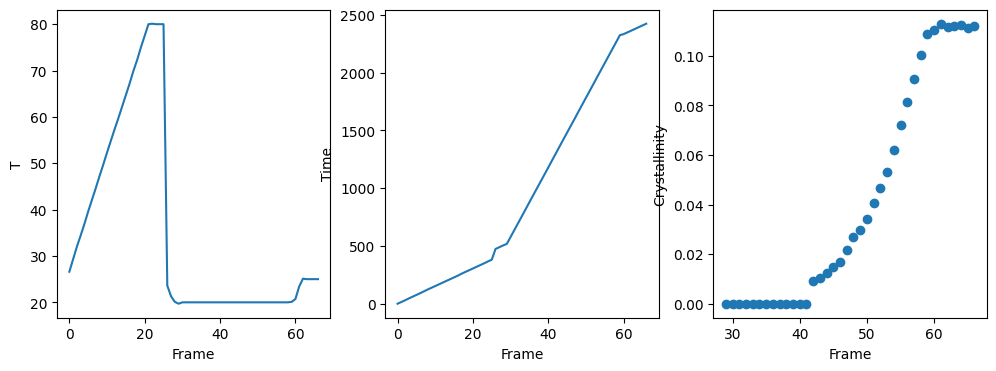

In [205]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info292_24_20C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][62:63]))

Чтение SAXS файла 63: PEG_PNIPAM_292_24_Cryst_at_20C_SAXS_0063.dat


array([7.10721594e-07, 2.16514006e+01, 1.81335541e-01, 1.92999024e-02,
       1.25880768e-02, 5.13020386e-01, 1.57416072e-01])

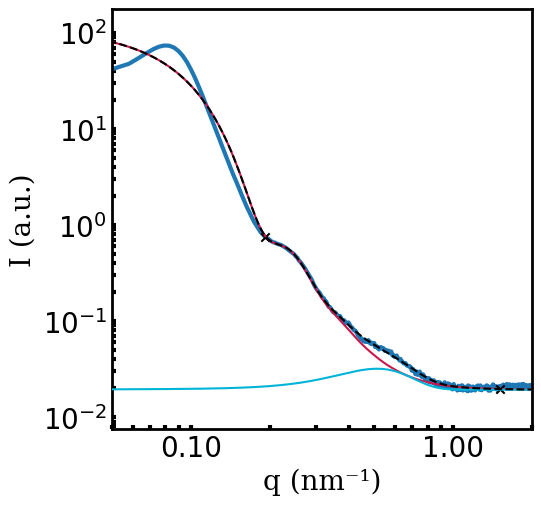

In [206]:
SAXS_plot(6,6)

q, I = Exp292_24_20C.get_1d_SAXS(63)
plt.plot(q, I, linewidth=3)

l = 54
r = 430
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[1.48800689e-06, 20, 1.18588026e-01, 1.13931544e-02 ])
p, cov = curve_fit(Spheres_norm, q[l:r], I[l:r], p0=[1e-06, 2.17410137e+01, 0.12, 1.74640436e-02,  1.14996878e-1, 0.65, 1.90167112e-01 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [207]:
2*p[1]

np.float64(43.302801153554455)

In [208]:
2*pi/p[5]

np.float64(12.24743786613995)

In [209]:
p[5]

np.float64(0.5130203864557241)

### 576_6

#### data

In [210]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_0C"
Exp576_6_0C = BM26_experiment(experiment_path)
Info576_6_0C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_0C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_10C"
Exp576_6_10C = BM26_experiment(experiment_path)
Info576_6_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_15C"
Exp576_6_15C = BM26_experiment(experiment_path)
Info576_6_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_15C.csv")

#### 0C

0.5357156671233869


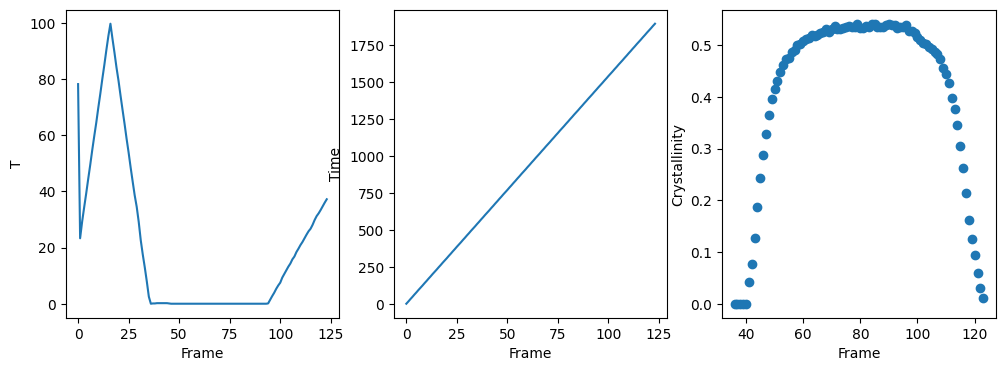

In [212]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_6_0C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][70:90]))

Чтение SAXS файла 20: PEG_PNIPAM_576_6_Cryst_0C_SAXS_0020.dat


array([ 5.25549615e-07,  1.71611130e+01,  1.32712530e-01,  1.54014212e+01,
       -1.53793428e+01,  5.88913781e-01,  4.75219239e+01])

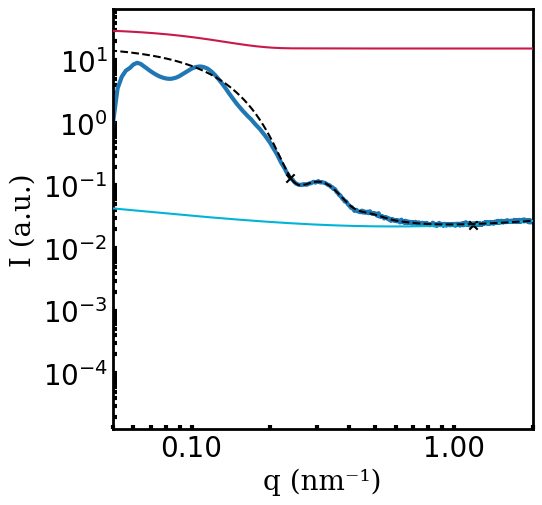

In [221]:
SAXS_plot(6,6)
Data = Exp576_6_0C
q, I = Data.get_1d_SAXS(20)
plt.plot(q, I, linewidth=3)

l = 120
r = 600
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 18, 0.12, 8.91806121e-05,  5.32180981e-03, 0.7, 0.2 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [222]:
2*p[1]

np.float64(34.322225965848205)

In [219]:
p[5]

np.float64(0.5934403934271735)

In [223]:
2*pi/0.11

57.11986642890533

#### 10C

0.4826496510685556


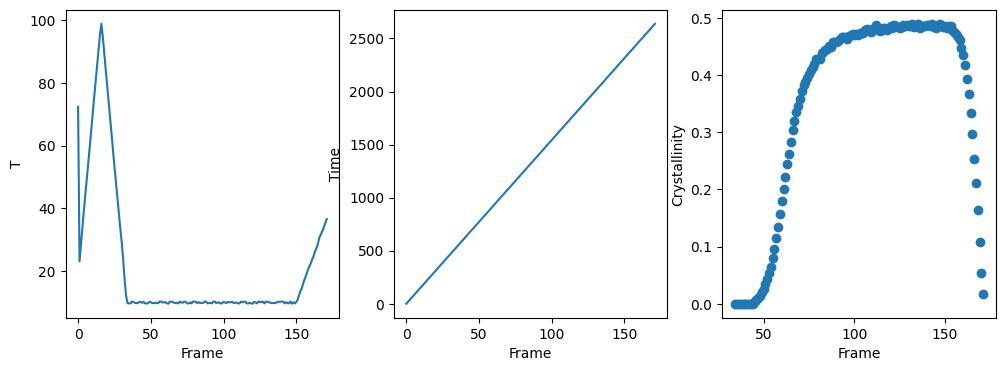

In [225]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_6_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][100:150]))

Чтение SAXS файла 100: PEG_PNIPAM_576_6_Cryst_10C_SAXS_0100.dat


array([1.60271661e-06, 1.80348700e+01, 1.09844200e-01, 2.04981033e-02,
       5.41923816e-02, 5.22616060e-01, 2.74296064e-01])

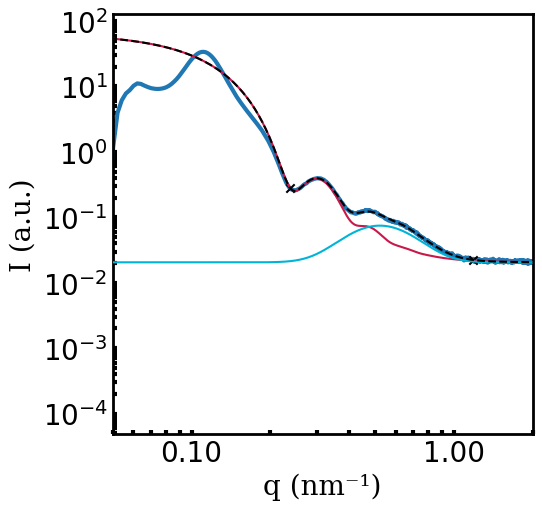

In [226]:
SAXS_plot(6,6)
Data = Exp576_6_10C
q, I = Data.get_1d_SAXS(100)
plt.plot(q, I, linewidth=3)

l = 120
r = 600
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 18, 0.12, 8.91806121e-05,  5.32180981e-02, 0.7, 0.2 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [227]:
2*pi/p[5]

np.float64(12.022564527020998)

In [228]:
2*p[1]

np.float64(36.069740049674465)

#### 15C

0.48610177900724727


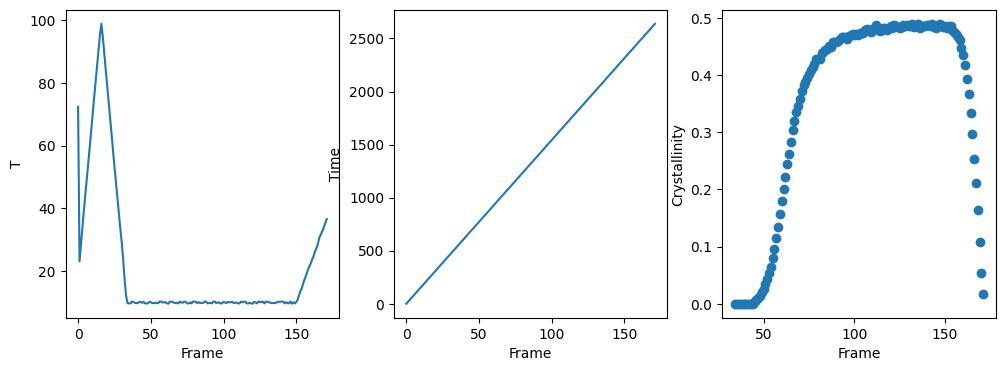

In [230]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_6_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][125:150]))

Чтение SAXS файла 150: PEG_PNIPAM_576_6_Cryst_15C_SAXS_0150.dat


array([1.10533877e-06, 1.79374858e+01, 1.17360571e-01, 2.11310669e-02,
       4.78801994e-02, 5.17542191e-01, 2.45011133e-01])

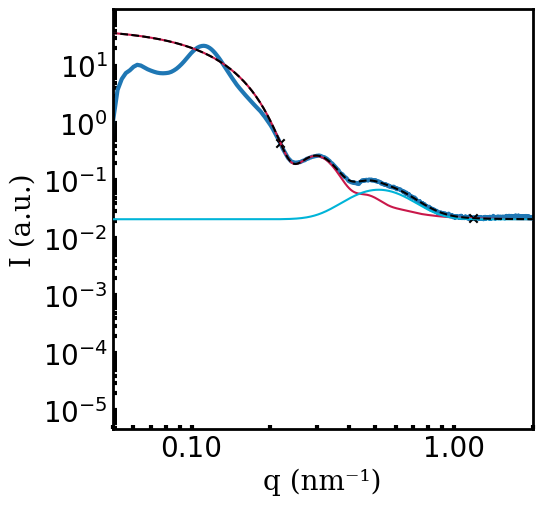

In [233]:
SAXS_plot(6,6)
Data = Exp576_6_15C
q, I = Data.get_1d_SAXS(150)
plt.plot(q, I, linewidth=3)

l = 110
r = 600
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 18, 0.12, 8.91806121e-05,  5.32180981e-02, 0.7, 0.2 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [234]:
2*p[1]

np.float64(35.8749715658882)

In [236]:
2*pi/p[5]

np.float64(12.140431092136721)

### 576_12

#### data

In [190]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_5C"
Exp576_12_5C = BM26_experiment(experiment_path)
Info576_12_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_10C"
Exp576_12_10C = BM26_experiment(experiment_path)
Info576_12_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_15C"
Exp576_12_15C = BM26_experiment(experiment_path)
Info576_12_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_15C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_20C"
Exp576_12_20C = BM26_experiment(experiment_path)
Info576_12_20C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_20C.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\PEG_PNIPAM crystallization\\Samodelkin data\\general\\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_20C.csv'

#### 5C

0.614609620636461


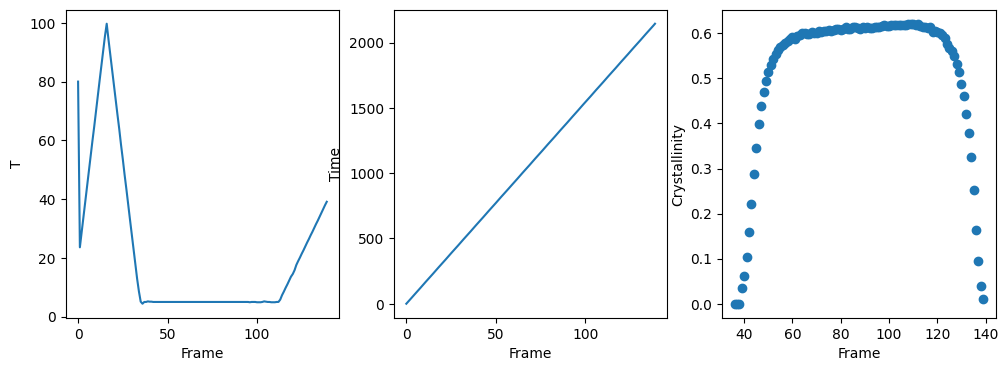

In [239]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_12_5C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][80:110]))

Чтение SAXS файла 40: PEG_PNIPAM_576_12_Cryst_5C_SAXS_0040.dat


array([ 2.55420750e-06,  1.65895461e+01,  1.74306558e-01,  3.63675761e-01,
       -3.42556696e-01,  9.08271715e-01,  1.93657548e+00])

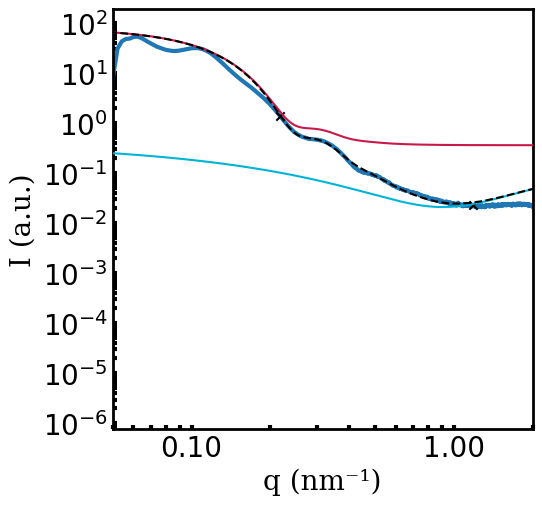

In [245]:
SAXS_plot(6,6)
Data = Exp576_12_5C
q, I = Data.get_1d_SAXS(40)
plt.plot(q, I, linewidth=3)

l = 110
r = 600
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 18, 0.12, 8.91806121e-05,  5.32180981e-02, 0.7, 0.2 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [246]:
2*p[1]

np.float64(33.17909227168095)

In [242]:
2*pi/p[5]

np.float64(10.808477438200692)

#### 10C

0.5996320192447826


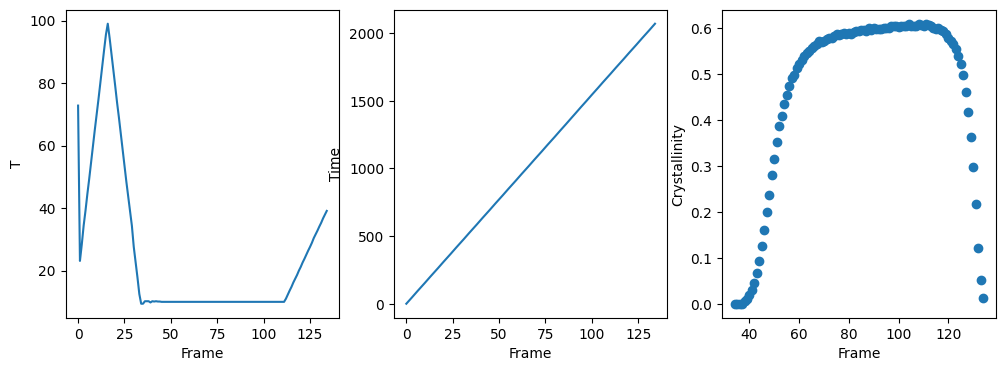

In [247]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_12_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][80:110]))

Чтение SAXS файла 100: PEG_PNIPAM_576_12_Cryst_10C_SAXS_0100.dat


array([4.15271174e-06, 1.75423095e+01, 1.43016563e-01, 1.64798349e-02,
       9.02815377e-02, 5.69923255e-01, 2.91781663e-01])

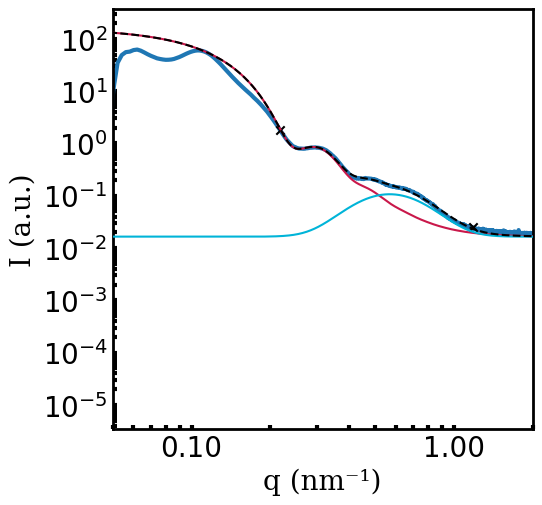

In [248]:
SAXS_plot(6,6)
Data = Exp576_12_10C
q, I = Data.get_1d_SAXS(100)
plt.plot(q, I, linewidth=3)

l = 110
r = 600
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 18, 0.12, 8.91806121e-05,  5.32180981e-02, 0.7, 0.2 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [249]:
2*p[1]

np.float64(35.084619057574926)

In [250]:
2*pi/p[5]

np.float64(11.024616483793022)

#### 15C

0.603098184466729


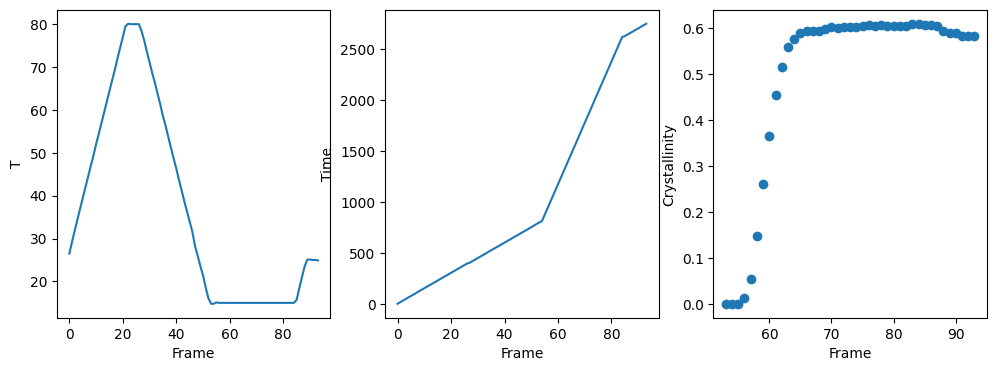

In [252]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_12_15C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][70:80]))

Чтение SAXS файла 80: PEG_PNIPAM_576_12_Cryst_15C_SAXS_0080.dat


array([3.44104777e-06, 1.73454327e+01, 1.59918080e-01, 1.85887825e-02,
       8.56299109e-02, 5.25907126e-01, 2.83303565e-01])

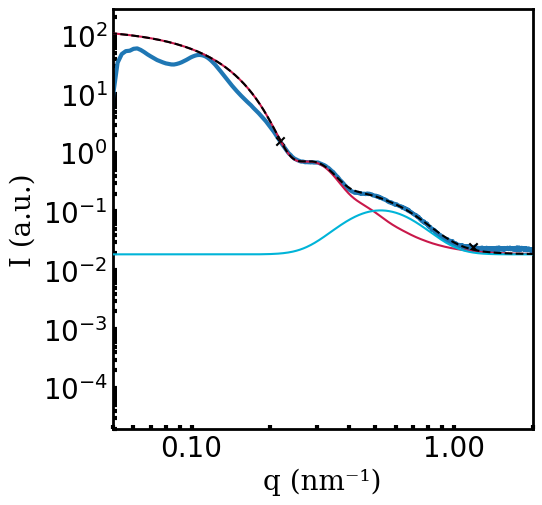

In [253]:
SAXS_plot(6,6)
Data = Exp576_12_15C
q, I = Data.get_1d_SAXS(80)
plt.plot(q, I, linewidth=3)

l = 110
r = 600
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 18, 0.12, 8.91806121e-05,  5.32180981e-02, 0.7, 0.2 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [254]:
2*p[1]

np.float64(34.690865389276205)

In [255]:
2*pi/p[5]

np.float64(11.94732870793805)

### 576_24

#### data

In [60]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_576_24_Cryst_at_15C_bis"
Exp576_24_15C = BM26_experiment(experiment_path)
Info576_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_15C_bis.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_5C"
Exp576_24_5C = BM26_experiment(experiment_path)
Info576_24_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_10C"
Exp576_24_10C = BM26_experiment(experiment_path)
Info576_24_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_20C"
Exp576_24_20C = BM26_experiment(experiment_path)
Info576_24_20C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_20C.csv")

#### 5C

0.6162250736744437


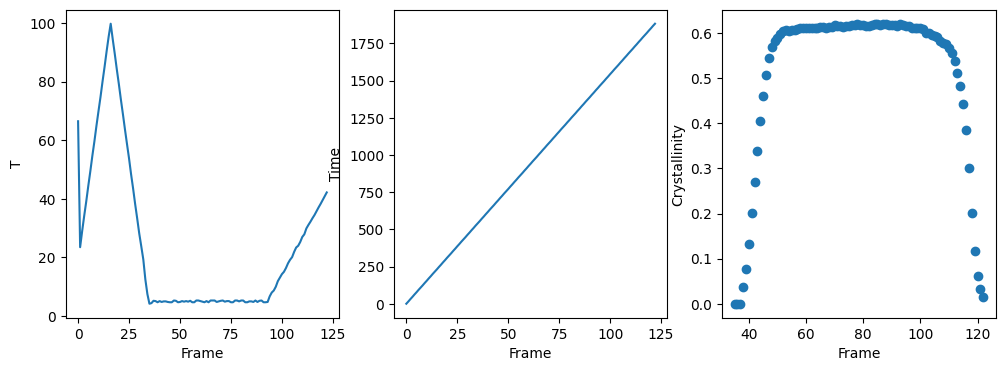

In [61]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_24_5C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][60:100]))

array([7.52193505e-07, 3.80623748e+01, 1.92913380e-01, 2.00000000e-02,
       7.97526755e-02, 6.88838887e-01, 1.81585065e-01])

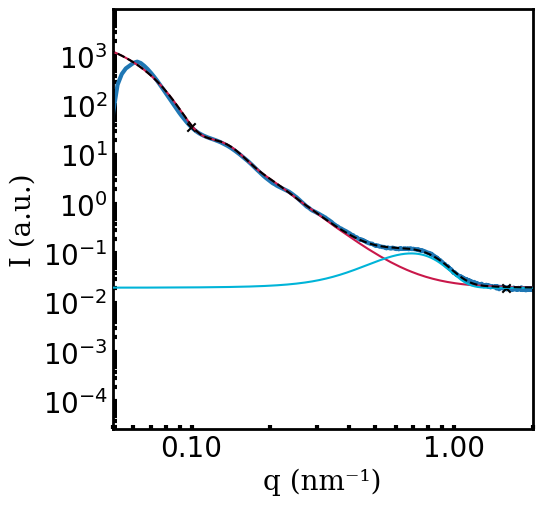

In [62]:
SAXS_plot(6,6)
Data = Exp576_24_5C
q, I = Data.get_1d_SAXS(100)
plt.plot(q, I, linewidth=3)

l = 50
r = 800
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')

#p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[3.00216313e-07, 3.78664118e+01, 2.17351876e-01, 1.26464688e-02])
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_norm, q[l:r], I[l:r],
                   p0=[6.89369061e-07, 38, 0.22, 1.8e-2, 0.1, 0.75, 0.2], 
                   bounds=((0, 30, 0, 0, 0, 0.5, 0),
                           (np.inf, 40, 0.5, 2e-2, np.inf, 1, np.inf)),
                   sigma = I[l:r])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))

#plt.plot(q, Spheres_norm(q, *[6.89369061e-07, 38, 0.22, 1.8e-2, 0.1, 0.75, 0.2]), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Spheres_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [63]:
2*p[1]

np.float64(76.12474955502935)

In [64]:
2*pi/p[5]

np.float64(9.121414933924072)

In [65]:
p[5]

np.float64(0.6888388865867033)

#### 10C

0.6216268163874076


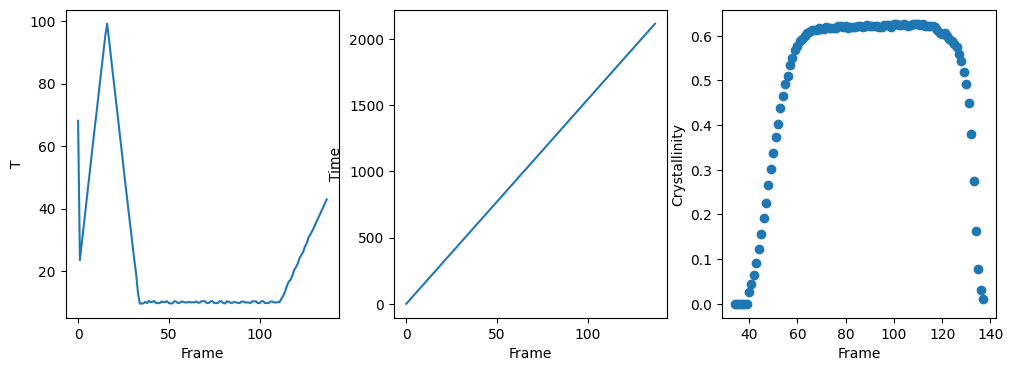

In [66]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_24_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][80:100]))

array([7.28989279e-07, 3.79513446e+01, 1.93835512e-01, 1.81731257e-02,
       8.76229725e-02, 6.62239403e-01, 1.76934869e-01])

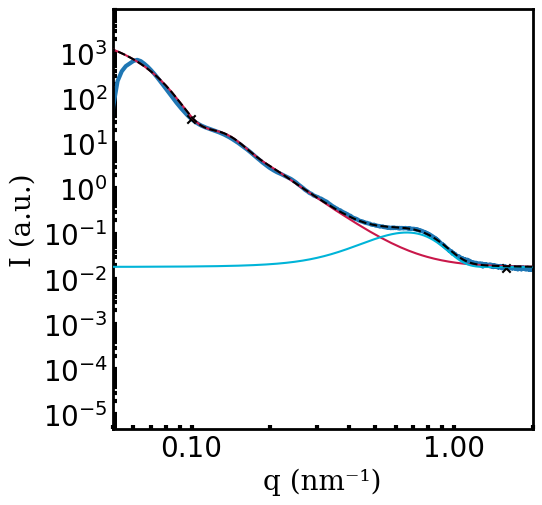

In [67]:
SAXS_plot(6,6)
Data = Exp576_24_10C
q, I = Data.get_1d_SAXS(100)
plt.plot(q, I, linewidth=3)

l = 50
r = 800
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')

#p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[3.00216313e-07, 3.78664118e+01, 2.17351876e-01, 1.26464688e-02])
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_norm, q[l:r], I[l:r],
                   p0=[6.89369061e-07, 38, 0.22, 1.8e-2, 0.1, 0.75, 0.2], 
                   bounds=((0, 30, 0, 0, 0, 0.5, 0),
                           (np.inf, 40, 0.5, 2e-2, np.inf, 1, np.inf)),
                   sigma = I[l:r])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))

#plt.plot(q, Spheres_norm(q, *[6.89369061e-07, 38, 0.22, 1.8e-2, 0.1, 0.75, 0.2]), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Spheres_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [68]:
2*p[1]

np.float64(75.90268927337493)

In [69]:
2*pi/p[5]

np.float64(9.487785356671697)

#### 15C

0.5690043735345953


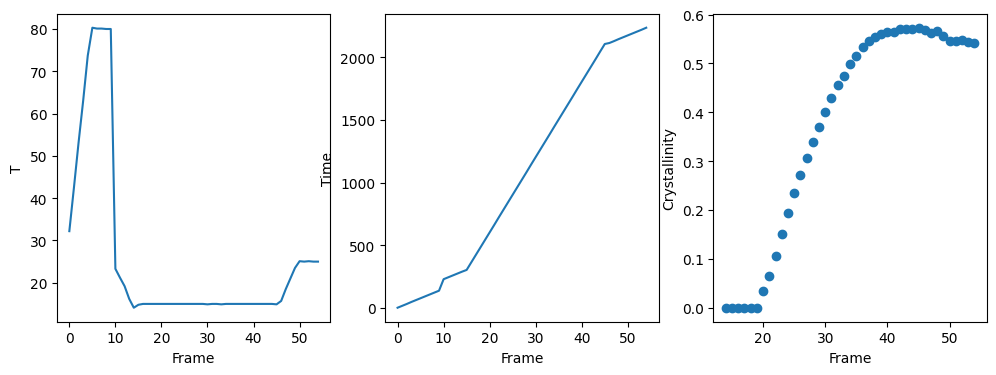

In [118]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_24_15C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][42:48]))

Чтение SAXS файла 48: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0048.dat


array([2.30553649e-07, 4.00000000e+01, 1.86686035e-01, 2.00000000e-02,
       9.02323528e-02, 5.78628405e-01, 1.97765138e-01])

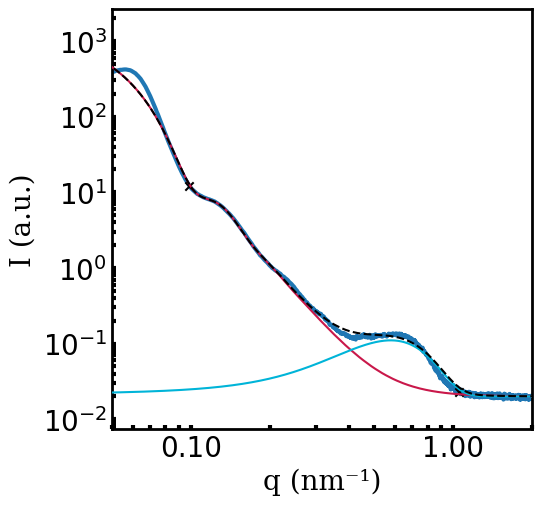

In [169]:
SAXS_plot(6,6)
Data = Exp576_24_15C
q, I = Data.get_1d_SAXS(48)
plt.plot(q, I, linewidth=3)

l = 140
r = 1500
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')

#p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[3.00216313e-07, 3.78664118e+01, 2.17351876e-01, 1.26464688e-02])
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_norm, q[l:r], I[l:r],
                   p0=[6.89369061e-07, 38, 0.22, 1.8e-2, 0.1, 0.75, 0.2], 
                   bounds=((0, 30, 0, 0, 0, 0.5, 0),
                           (np.inf, 40, 0.5, 2e-2, np.inf, 1, np.inf)),
                   #sigma = I[l:r]
                  )
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))

#plt.plot(q, Spheres_norm(q, *[6.89369061e-07, 38, 0.22, 1.8e-2, 0.1, 0.75, 0.2]), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Spheres_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [167]:
2*p[1]

np.float64(78.42639044439147)

In [168]:
2*pi/p[5]

np.float64(12.566370611454433)

#### 20C

0.1208142604823955


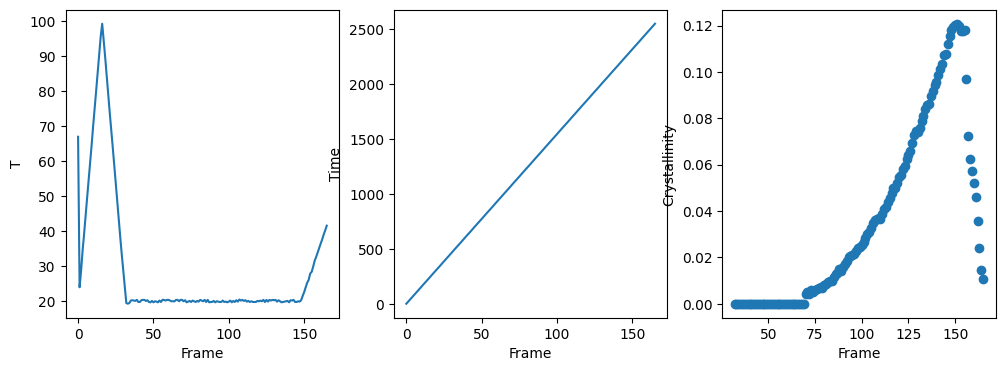

In [128]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info576_24_20C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(max(Info['Crystalinity'].fillna(0)))

Чтение SAXS файла 0: PEG_PNIPAM_576_24_Cryst_10C_SAXS_0000.dat


array([3.33841397e-07, 3.70186267e+01, 1.99793720e-01, 1.75718143e-02,
       4.98607973e-03, 5.00000000e-01, 1.71888367e-01])

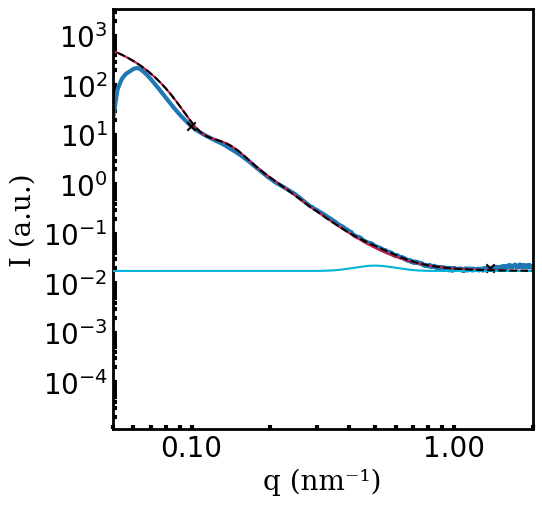

In [178]:
SAXS_plot(6,6)
Data = Exp576_24_10C
q, I = Data.get_1d_SAXS(0)
plt.plot(q, I, linewidth=3)

l = 50
r = 700
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')

#p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[3.00216313e-07, 3.78664118e+01, 2.17351876e-01, 1.26464688e-02])
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r],
                   p0=[6.89369061e-07, 38, 0.22, 1.8e-2, 0., 0.75, 0.2], 
                   bounds=((0, 30, 0, 0, 0, 0.5, 0),
                           (np.inf, 40, 0.5, 2e-2, np.inf, 1, np.inf)),
                   sigma = I[l:r])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))

#plt.plot(q, Spheres_norm(q, *[6.89369061e-07, 38, 0.22, 1.8e-2, 0.1, 0.75, 0.2]), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [179]:
2*p[1]

np.float64(74.0372534025728)

In [175]:
2*pi/p[5]

np.float64(12.566370614358101)

### 888_20

#### 15C

0.584996855271745


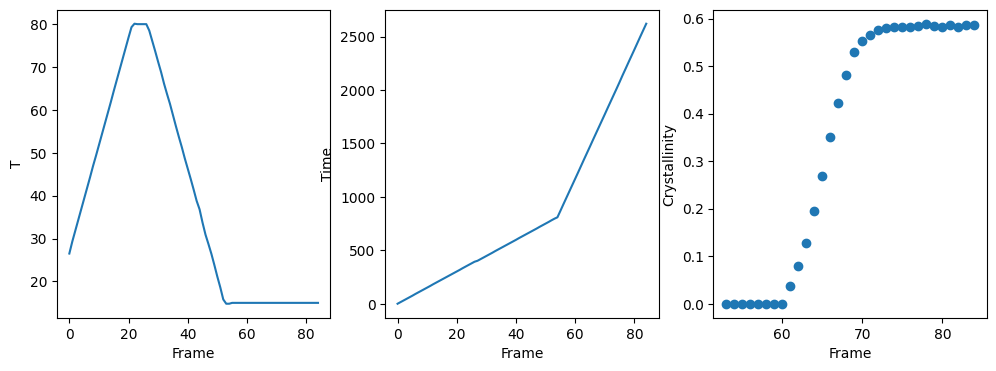

In [182]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
Info = Info888_24_15C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].scatter(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
print(np.mean(Info['Crystalinity'][75:85]))

Чтение SAXS файла 60: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0060.dat


array([1.08794784e-07, 3.49366416e+01, 1.53581936e-01, 1.44641367e-02,
       2.31818222e-16, 5.02412053e-01, 4.52403302e-07])

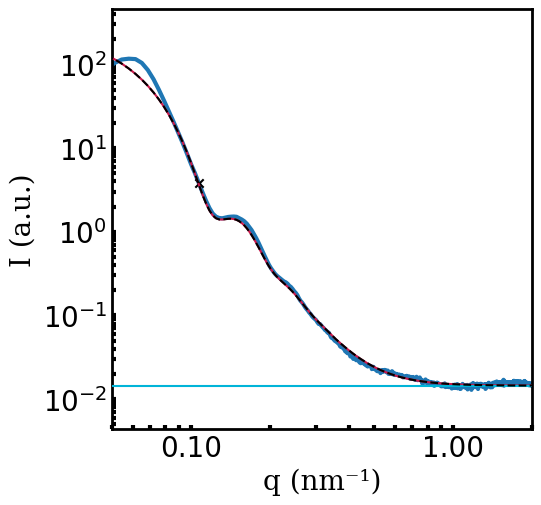

In [188]:
SAXS_plot(6,6)
Data = Exp888_24_15C
q, I = Data.get_1d_SAXS(60)
plt.plot(q, I, linewidth=3)

l = 30
r = 700
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')

#p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[3.00216313e-07, 3.78664118e+01, 2.17351876e-01, 1.26464688e-02])
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r],
                   p0=[6.89369061e-07, 38, 0.22, 1.8e-2, 0., 0.75, 0.2], 
                   bounds=((0, 30, 0, 0, 0, 0.5, 0),
                           (np.inf, 40, 0.5, 2e-2, np.inf, 1, np.inf)),
                   sigma = I[l:r])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))

#plt.plot(q, Spheres_norm(q, *[6.89369061e-07, 38, 0.22, 1.8e-2, 0.1, 0.75, 0.2]), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [189]:
2*p[1]

np.float64(69.87328325884876)

In [187]:
2*pi/p[5]

np.float64(10.568958638809292)

# Data Save

Чтение SAXS файла 70: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0070.dat
Чтение SAXS файла 60: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0060.dat


(0.01, 10.0)

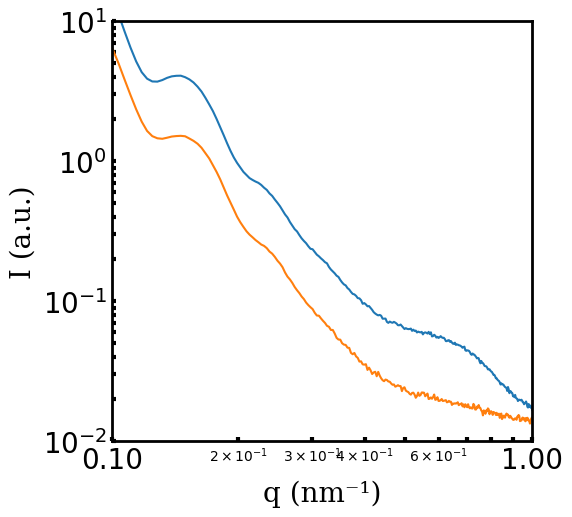

In [42]:
SAXS_plot(6,6)
q, I = Exp888_24_15C.get_1d_SAXS(70)
plt.plot(q, I)
q, I = Exp888_24_15C.get_1d_SAXS(60)
plt.plot(q, I)
plt.xlim(0.1, 1)
plt.ylim(1e-2, 1e1)

df = pd.DataFrame({'q':q*0.1, 'I':I, 'err':np.zeros(len(q))})
df.to_csv(r"C:\Users\LabPC\Desktop/S888_24.txt", sep=str('\t'), index=0)

# Plots for article

In [11]:
def average_1d_SAXS(Exp, frames):
    q, I = Exp.get_1d_SAXS()
    I *= 0
    for i in frames:
        q_frame, I_frame = Exp.get_1d_SAXS(i)
        I += I_frame
    I /= len(frames)
    return q, I

## Melt analysis

Чтение SAXS файла 0: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0000.dat
Чтение SAXS файла 9: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0009.dat
Чтение SAXS файла 10: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0010.dat
Чтение SAXS файла 11: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0011.dat
Чтение SAXS файла 12: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0012.dat
Чтение SAXS файла 13: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0013.dat
Чтение SAXS файла 14: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0014.dat
Чтение SAXS файла 15: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0015.dat
Чтение SAXS файла 16: PEG_PNIPAM_888_24_Cryst_at_15C_SAXS_0016.dat
Чтение SAXS файла 0: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0000.dat
Чтение SAXS файла 6: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0006.dat
Чтение SAXS файла 7: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0007.dat
Чтение SAXS файла 8: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0008.dat
Чтение SAXS файла 9: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0009.dat
Чтение SAXS файла 10: PEG_PNIPAM_576_24_Cryst_at_

(2e-06, 10000.0)

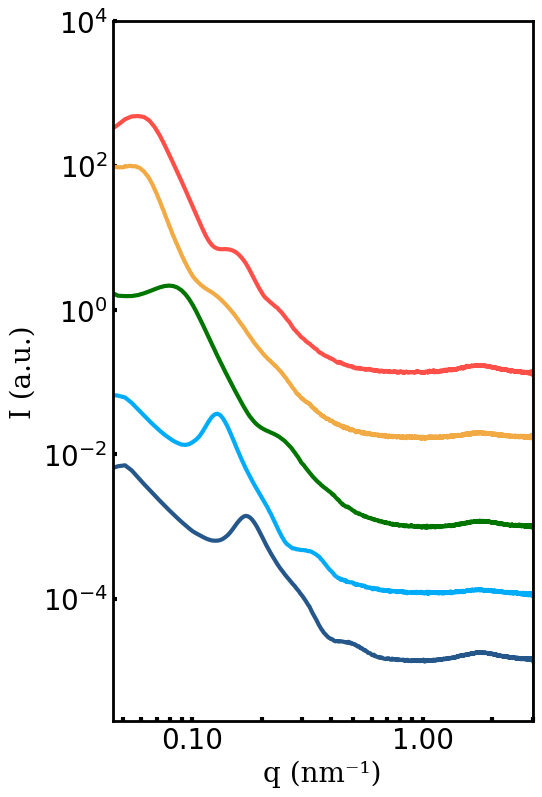

In [12]:
SAXS_plot(6,10)
linewidth=3
q, I = average_1d_SAXS(Exp888_24_15C, [9,10,11, 12, 13,14,15,16])
plt.plot(q, I*10, linewidth=linewidth, color='#FF4F49')

q, I = average_1d_SAXS(Exp576_24_15C, [6,7,8,9,10,11,12,13])
I[:68] += 8
I[68:73] += 10
plt.plot(q, I, linewidth=linewidth, color='#F2AA44')

q, I =  average_1d_SAXS(Exp292_24_15C, [7,8,9,10,12,13])
plt.plot(q, I/15, linewidth=linewidth, color='#007500')

q, I =  average_1d_SAXS(Exp292_12_10C, [14,15,16,17,18,19,20])
plt.plot(q, I/100, linewidth=linewidth, color='#00ABF8')

q, I =  average_1d_SAXS(Exp292_12_10C, [14,15,16,17,18,19,20])
#plt.plot(q, I/100, linewidth=linewidth, color='#5C9AE3')

q, I =  average_1d_SAXS(Exp292_6_0C, [35,36,37,38,39,40,41,42])
plt.plot(q, I/2000, linewidth=linewidth, color='#25578A')
plt.xlim(0.045, 3)

plt.ylim(2e-6, 1e4)

C:\Users\LabPC\AppData\Local\Temp\ipykernel_7492\1283148964.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X[5] = x


array([0.62518457, 0.48337935])

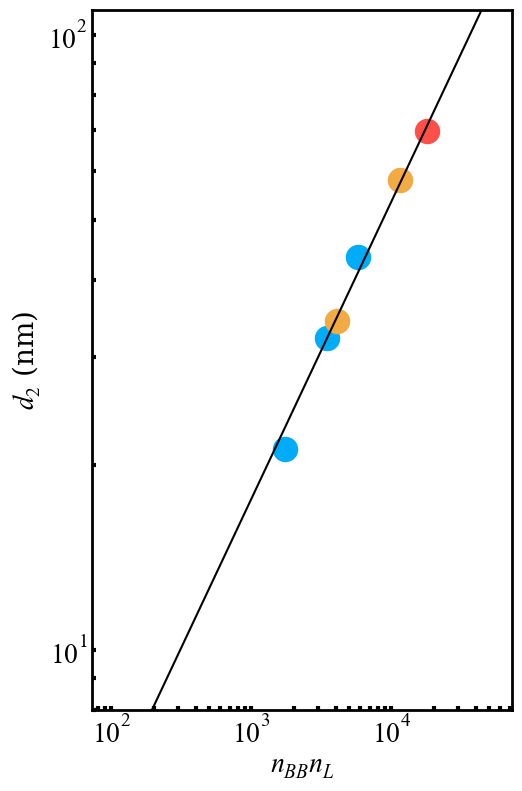

In [321]:
font = {'family': 'serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }
    
fig, ax = plt.subplots(figsize=(6,10))
ax.set_position([0.15, 0.15, 0.7, 0.7])
    
plt.semilogx()
plt.semilogy()

plt.xlabel('$n_{BB} n_L$', fontdict = font)
plt.ylabel('$d_2$ (nm)', fontdict = font)

plt.xticks(fontsize=20)
plt.yticks([1e1, 1e2], fontsize=20)
plt.ylim(0.8e1, 1.1e2)


#plt.xlabel('φ (%)', fontdict = font)
#plt.ylabel('d (nm)', fontdict = font)
X = np.zeros(6)
Y = np.zeros(6)

nBB = 290
nL = np.array([6,12,20])
x = nL*nBB
plt.scatter(x, [21.2, 32.2, 43.5], s=300, color='#00ABF8', label='290')
X[:3] = x
Y[:3] = [21.2, 32.2, 43.5]

nBB = 580
nL = np.array([7,20])   
x = nL*nBB
plt.scatter(x, [34.3, 58.2], s=300, color='#F2AA44', label='580')
X_array.append(nL*nBB)
X[3:5] = x
Y[3:5] = [34.3, 58.2]

nBB = 890
nL = np.array([20])   
x = nL*nBB
plt.scatter(x, [69.9], s=300, color='#FF4F49', label='890')
X[5] = x
Y[5] = 69.9

p, cov = curve_fit(power, X, Y)
lnsp = np.linspace(1e2, max(X)*3)
plt.plot(lnsp, power(lnsp, *p), color='black')
ax.tick_params(axis="both",which='both',direction="in", width=3, length=3)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
#plt.legend()
p

# 2D Plots

In [249]:
import pyFAI
import matplotlib.colors as colors
path_to_poni = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\SAXS_4m_12keV_linkam.poni"
ai = pyFAI.load(path_to_poni)
ai

Detector Pilatus 1M	 PixelSize= 172µm, 172µm	 BottomRight (3)
Wavelength= 1.033202e-10 m
SampleDetDist= 3.946447e+00 m	PONI= 6.595799e-03, 1.493440e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 3946.447 mm	Center: x=868.279, y=38.348 pix	Tilt= 0.000° tiltPlanRotation= 0.000° 𝛌= 1.033Å

In [242]:
lmbda = 1.033202e-10
pixel_size = 1.720e-04
SDD = 3.946447
PX0 = 868.279
PY0 = 38.348

In [232]:
x = 2*pi*np.sin((np.array(range(981))-PX0)*pixel_size/SDD)/lmbda/10e8
y = 2*pi*np.sin((np.array(range(1043))-PY0)*pixel_size/SDD)/lmbda/10e8

In [289]:
path_to_img = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_0C\SAXS\PEG_PNIPAM_292_6_Cryst_at_0_SAXS_0000.edf"
img = fabio.open(path_to_img).data

C:\Users\LabPC\AppData\Local\Temp\ipykernel_7492\3262598010.py:18: RuntimeWarning: invalid value encountered in log10
  mesh = ax1.pcolormesh(-x, y, np.log10(img + 1e-3), vmin=0.3, vmax=3.5, cmap='jet',rasterized=True)


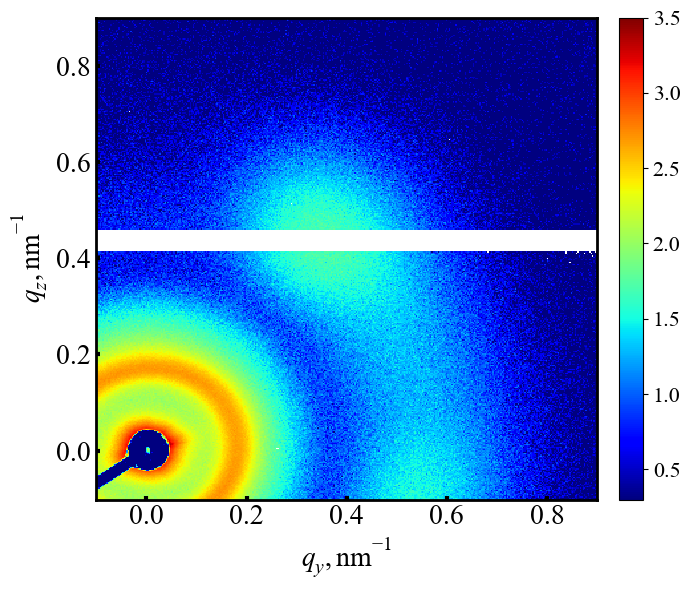

In [305]:
fig, ax1 = plt.subplots(1, 1, figsize=(7,6), layout='tight')
ax.set_position([0.15, 0.15, 0.7, 0.7])
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

ax1.tick_params(axis='both', which='major', labelsize=20, direction="in", width=3, length=3)

i = 5

cmap = plt.cm.jet
cmap.set_bad(color='black')  # для NaN
cmap.set_over(color='black')  # для значений > vmax
cmap.set_under(color='black') # для значений < vmin

mesh = ax1.pcolormesh(-x, y, np.log10(img + 1e-3), vmin=0.3, vmax=3.5, cmap='jet',rasterized=True)


ax1.set_xlabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Times New Roman', fontweight='bold')
ax1.set_ylabel('$q_{z},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Times New Roman', fontweight='bold')
ax1.set_xlim(min(y), 0.9)
ax1.set_ylim(min(y), 0.9)

#ticks = [-1.5, -1, -0.5,0, 0.5, 1, 1.5]
#ax1.set_xticks(ticks)
#ax1.set_yticks(ticks)

#cbar = fig.colorbar(mesh, ax=ax1, fraction=0.046, pad=0.04)
#cbar.ax.tick_params(labelsize=16)

"""save_dir = r'/Users/zokirzhonumarov/Desktop/LAB/Механика/PMMA-PDMS 2d'
save_filename = 'l2p25.tiff'

save_path = os.path.join(save_dir, save_filename)

fig.savefig(save_path, dpi=300, bbox_inches='tight')"""
#ax.tick_params(axis="both",which='both',direction="in", width=3, length=3)

for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)
cbar = fig.colorbar(mesh, ax=ax1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=16)
plt.show()

# Previous results

np.int64(76)

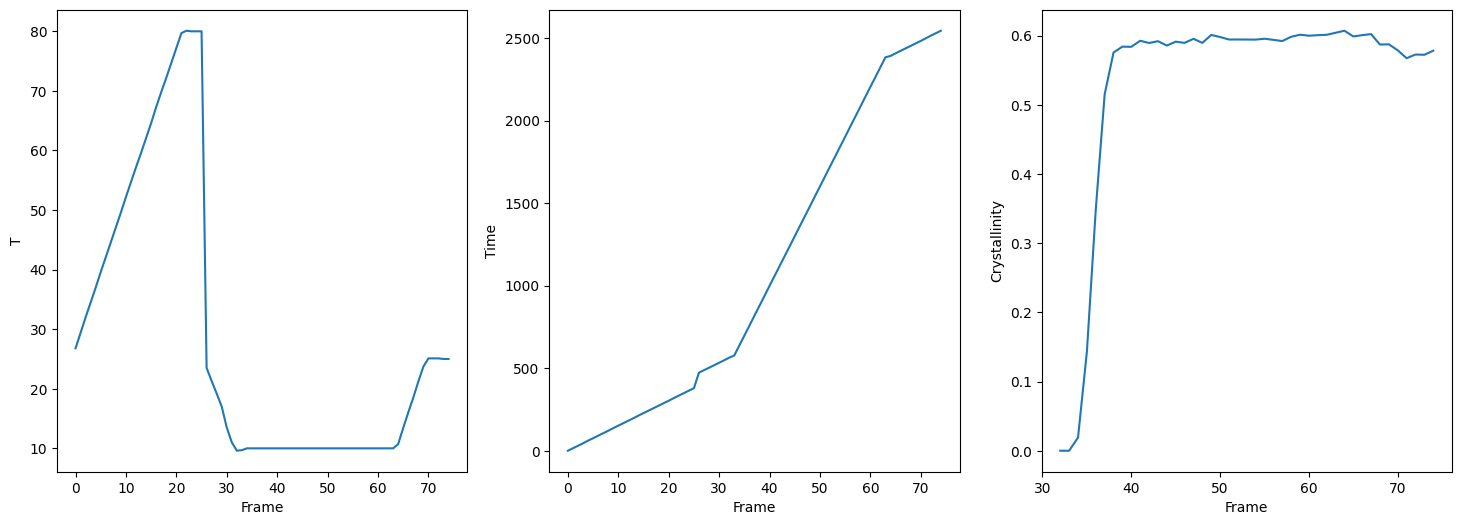

In [93]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_12_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
Info['Time'][5]
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

### 292-6 10C

Unnamed: 0
0        0
1       15
2       30
3       45
4       61
      ... 
93    2741
94    2757
95    2772
96    2787
97    2802
Name: Time, Length: 98, dtype: int64

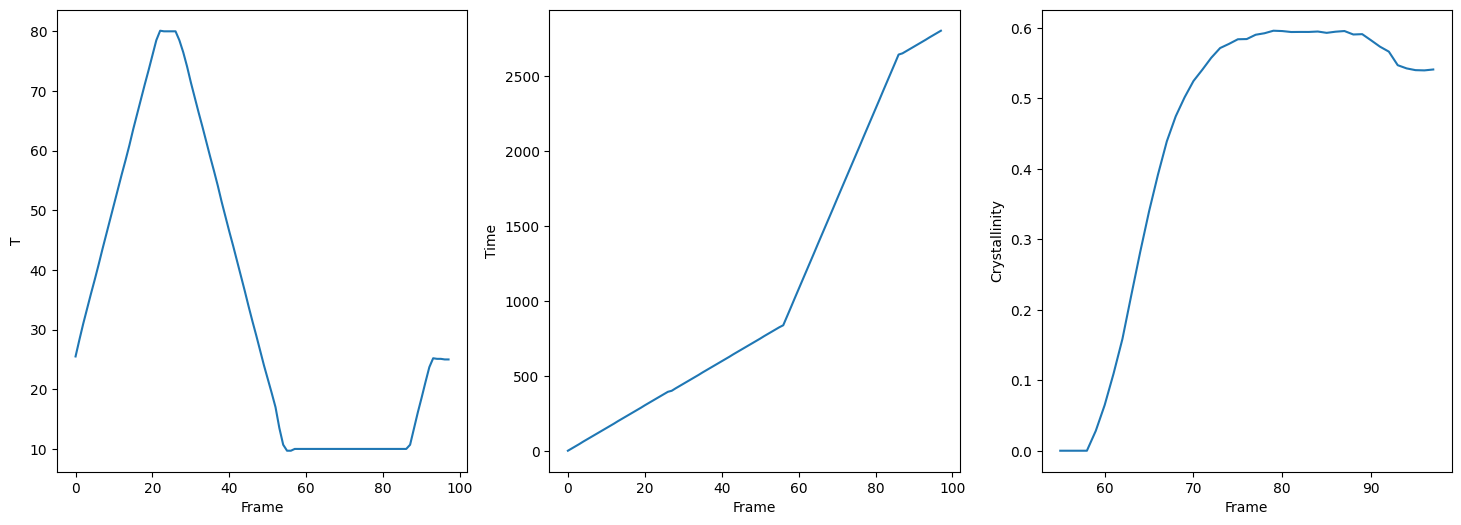

In [77]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_6_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
Info['Time'][5]
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 57: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0057.dat
Чтение WAXS файла 61: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0061.dat
Чтение WAXS файла 65: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0065.dat
Чтение WAXS файла 69: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0069.dat
Чтение WAXS файла 75: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0075.dat


(-0.1, 11.0)

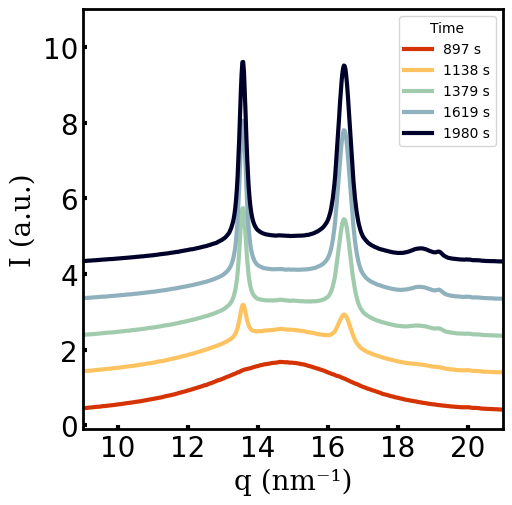

In [93]:
WAXS_plot(6,6)

lnwdth = 3
k = 1.5
times = [57,61,65,69,75]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp292_6_10C.get_1d_WAXS(times[0])
plt.plot(q, I/1000 , linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp292_6_10C.get_1d_WAXS(times[1])
plt.plot(q, I/1000 + 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp292_6_10C.get_1d_WAXS(times[2])
plt.plot(q, I/1000 + 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp292_6_10C.get_1d_WAXS(times[3])
plt.plot(q, I/1000 + 3, linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp292_6_10C.get_1d_WAXS(times[4])
plt.plot(q, I/1000 + 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(9, 21)
plt.ylim(-0.1, 11)

Чтение SAXS файла 57: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0057.dat
Чтение SAXS файла 61: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0061.dat
Чтение SAXS файла 65: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0065.dat
Чтение SAXS файла 69: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0069.dat
Чтение SAXS файла 75: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0075.dat


(0.008, 1300.0)

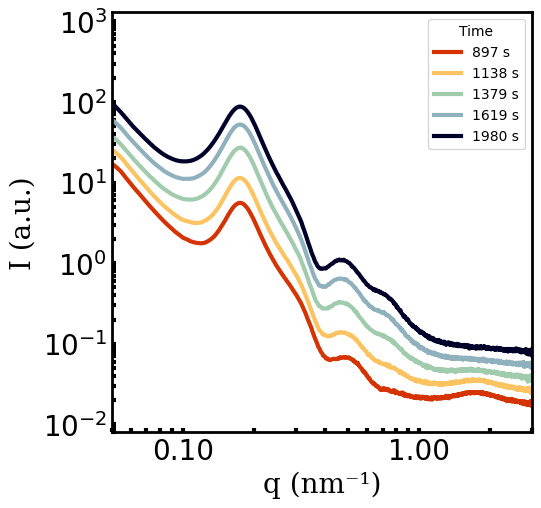

In [94]:
SAXS_plot(6,6)

lnwdth = 3
k = 1.5
times = [57,61,65,69,75]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp292_6_10C.get_1d_SAXS(times[0])
plt.plot(q, I, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp292_6_10C.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp292_6_10C.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp292_6_10C.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp292_6_10C.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(0.05, 3)
plt.ylim(0.8e-2, 13e2)

### 292_12 10C

(30.0, 40.0)

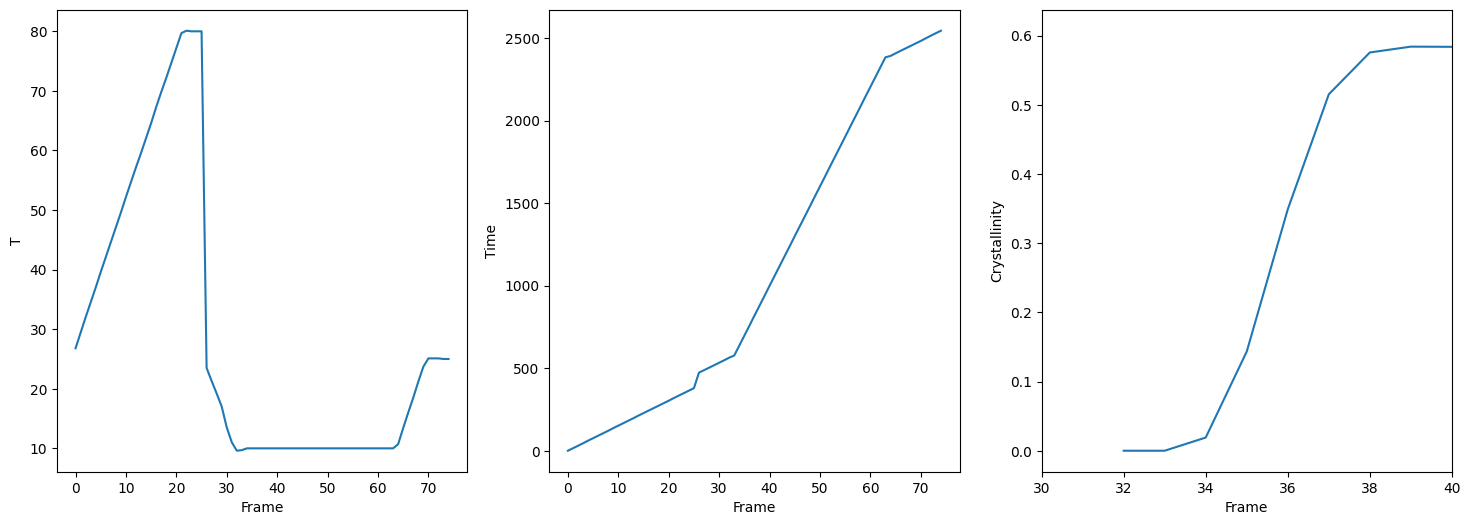

In [206]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_12_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
ax[2].set_xlim([30,40])
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 32: PEG_PNIPAM_292_12_Cryst_at_10C_WAXS_0032.dat
Чтение WAXS файла 34: PEG_PNIPAM_292_12_Cryst_at_10C_WAXS_0034.dat
Чтение WAXS файла 35: PEG_PNIPAM_292_12_Cryst_at_10C_WAXS_0035.dat
Чтение WAXS файла 36: PEG_PNIPAM_292_12_Cryst_at_10C_WAXS_0036.dat
Чтение WAXS файла 40: PEG_PNIPAM_292_12_Cryst_at_10C_WAXS_0040.dat


(-0.1, 3.4)

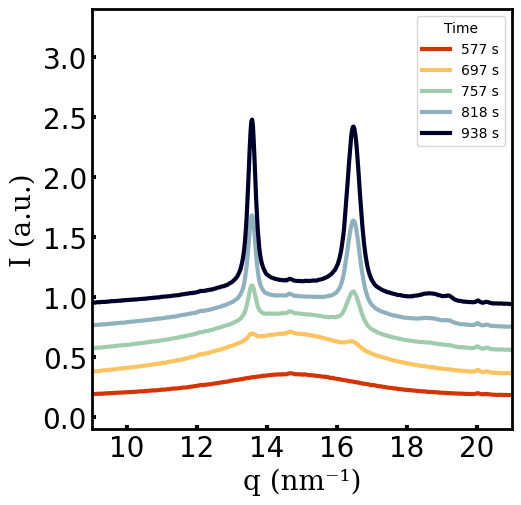

In [207]:
WAXS_plot(6,6)
Exp = Exp292_12_10C
lnwdth = 3
k = 0.2
times = [33,35,36,37,39]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_WAXS(32)
plt.plot(q, I/1000+0.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_WAXS(34)
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_WAXS(35)
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_WAXS(36)
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_WAXS(40)
plt.plot(q, I/1000+ k*4,   linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(9, 21)
plt.ylim(-0.1, 3.4)

Чтение SAXS файла 32: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0032.dat
Чтение SAXS файла 35: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0035.dat
Чтение SAXS файла 36: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0036.dat
Чтение SAXS файла 37: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0037.dat
Чтение SAXS файла 39: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0039.dat


(0.005, 2000.0)

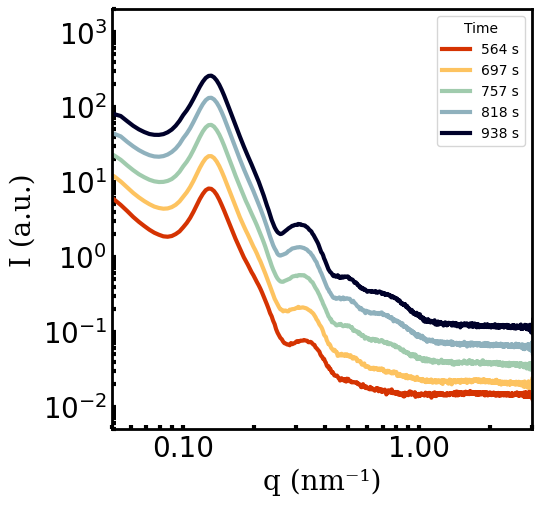

In [208]:
SAXS_plot(6,6)
Exp = Exp292_12_10C
lnwdth = 3
k = 1.8
times = [32,35,36,37,39]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_SAXS(times[0])
plt.plot(q, I/1.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')
plt.xlim(0.05, 3)
plt.ylim(0.5e-2, 20e2)

In [209]:
Info.iloc[38]

Time            878.000000
Temperature      10.000000
Crystalinity      0.575611
D 120            22.288359
D 032            12.913316
q1_Ampl           0.000000
Name: 38, dtype: float64

Чтение SAXS файла 40: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0040.dat


array([1.49205642e-06, 1.71414646e+01, 1.19305052e-01, 1.06023102e-02,
       1.21810428e-02, 7.08490026e-01, 2.08107123e-01])

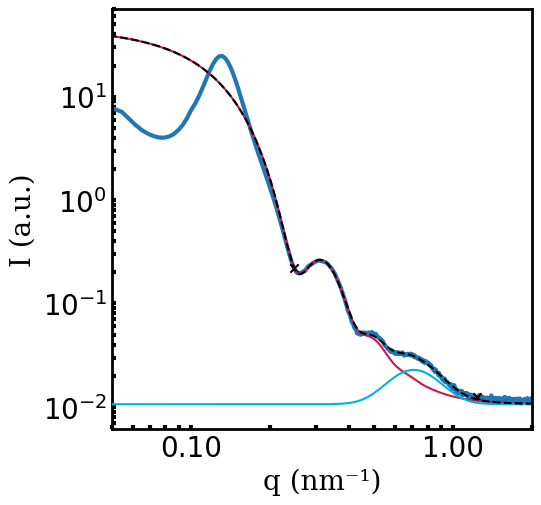

In [210]:
SAXS_plot(6,6)

q, I = Exp292_12_10C.get_1d_SAXS(40)
plt.plot(q, I, linewidth=3)

l = 70
r = 350
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [171]:
Spheres_log_norm

<function __main__.Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s)>

In [202]:
Params_df = pd.DataFrame({'frame':range(60, 32, -1), 'Ravg':np.zeros(28), 'q0':np.zeros(28), 'p':np.zeros(28)})
Params_array = []
p0 = [1.49205642e-06, 1.71414646e+01, 1.19305052e-01, 1.06023102e-02,
       1.21810428e-02, 7.08490026e-01, 2.08107123e-01]

j = 0
for i in Params_df['frame']:
    print(i)
    q, I = Exp292_12_10C.get_1d_SAXS(i)

    p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=p0)
    Params_array.append(p)
    Params_df['Ravg'].iloc[j] = p[1]
    
    Params_df['q0'].iloc[j] = p[5]
    Params_df['p'].iloc[j] = p[2]
    j += 1
    p0 = p


60
Чтение SAXS файла 60: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0060.dat


C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: SettingWithCopyWarning: 
A v

59
Чтение SAXS файла 59: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0059.dat


C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: SettingWithCopyWarning: 
A v

58
Чтение SAXS файла 58: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0058.dat


...

C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: SettingWithCopyWarning: 
A v

34
Чтение SAXS файла 34: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0034.dat


C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: SettingWithCopyWarning: 
A v

33
Чтение SAXS файла 33: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0033.dat


C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_6284\2916250556.py:13: SettingWithCopyWarning: 
A v

array([ 1.71481284e+01,  1.08204965e-02, -2.52537932e+02])

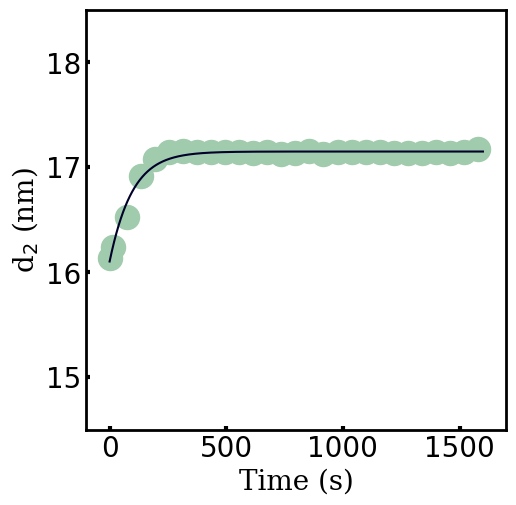

In [211]:
fig, ax = plt.subplots(figsize=(6, 6))
font = {'family': 'serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }
linewidth = 3
k = 1
ax.set_position([0.15, 0.15, 0.7, 0.7])

plt.scatter(Info['Time'][32:60][::-1] - 564, Params_df['Ravg'], s = 300,color='#A0CBAD')

p, cov = curve_fit(sigmoid, Info['Time'][32:60][::-1] - 564, Params_df['Ravg'], p0=[17, 0.1, 0])
plt.plot(np.linspace(0, 1600, 1000), sigmoid(np.linspace(0, 1600, 1000), *p), color='#00012A')

plt.xlabel('Time (s)', fontdict = font)
plt.ylabel('d${_2}$ (nm)', fontdict = font)

#ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both",which='both',direction="in", width=3, length=3)
#ax.minorticks_off()

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.set_position([0.15, 0.15, 0.7, 0.7])
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax.set_xlabel('Time (s)', fontdict = font)
ax.tick_params(axis="both",which='both',direction="in", width=3, length=3, labelsize=20)
#plt.yticks([10.5, 11, 11.5, 12])
#plt.xticks([0, 500, 1000, 1500])
plt.xlim(-100, 1700)
#plt.ylim(10.3, 12.1)
plt.ylim(14.5, 18.5)
p

### 292-24 10C

(30.0, 45.0)

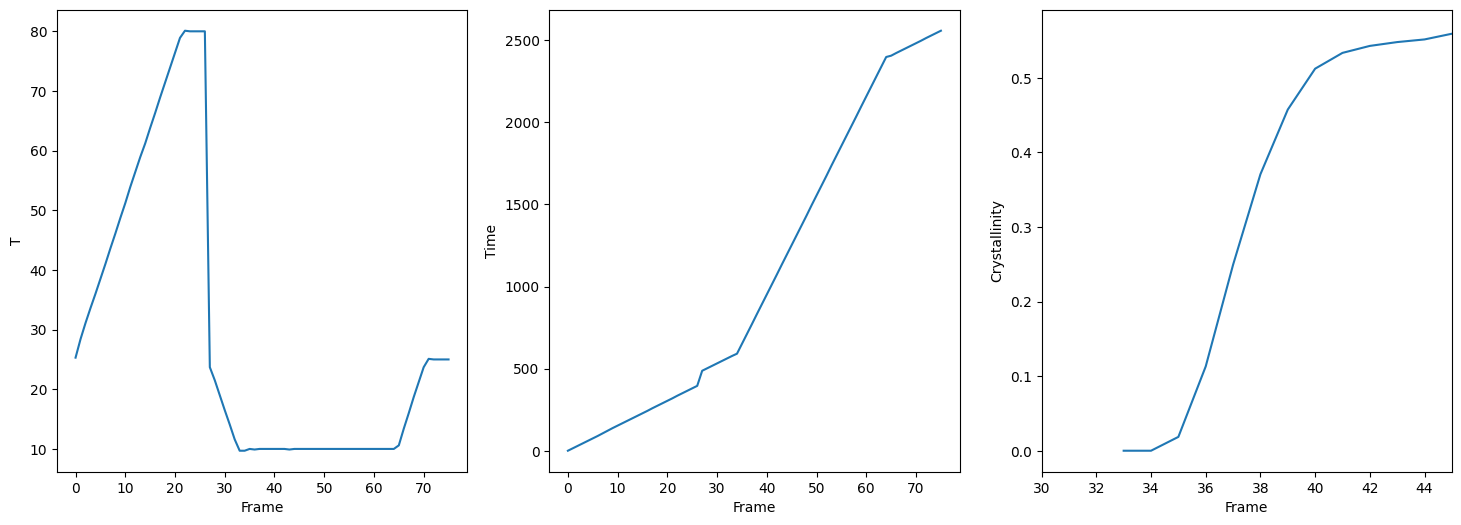

In [110]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_24_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
ax[2].set_xlim([30,45])
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 34: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0034.dat
Чтение WAXS файла 35: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0035.dat
Чтение WAXS файла 37: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0037.dat
Чтение WAXS файла 38: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0038.dat
Чтение WAXS файла 40: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0040.dat


(-0.1, 6.0)

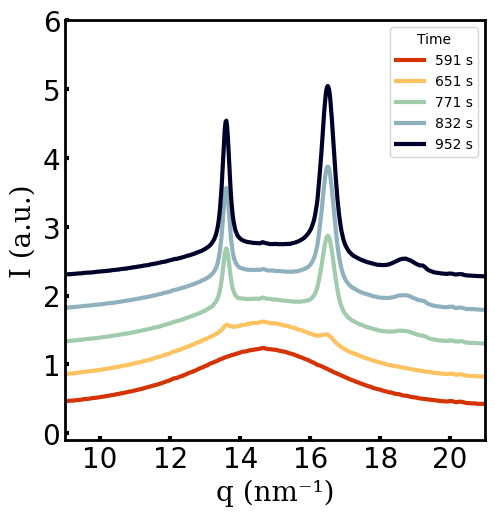

In [117]:
WAXS_plot(6,6)
Exp = Exp292_24_10C
lnwdth = 3
k = 0.5
times = [34,35,37,38,40]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_WAXS(times[0])
plt.plot(q, I/1000+0.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_WAXS(times[1])
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_WAXS(times[2])
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_WAXS(times[3])
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_WAXS(times[4])
plt.plot(q, I/1000+ k*4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(9, 21)
plt.ylim(-0.1, 6)

N_bb effect 292_24_15

Чтение SAXS файла 34: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0034.dat
Чтение SAXS файла 35: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0035.dat
Чтение SAXS файла 37: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0037.dat
Чтение SAXS файла 38: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0038.dat
Чтение SAXS файла 40: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0040.dat


(0.0102, 8000.0)

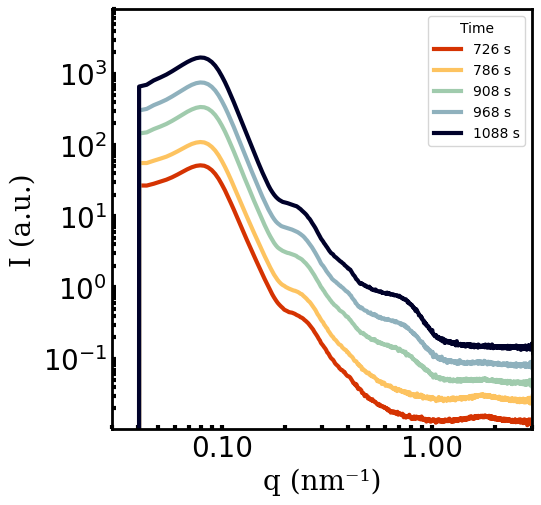

In [157]:
SAXS_plot(6,6)
Exp = Exp292_24_10C
lnwdth = 3
k = 1.8
times = [34,35,37,38,40]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_SAXS(times[0])
plt.plot(q, I/1.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(0.03, 3)
plt.ylim(1.02e-2, 8e3)

BOTTLEBRUSH EFFECT

(32.0, 60.0)

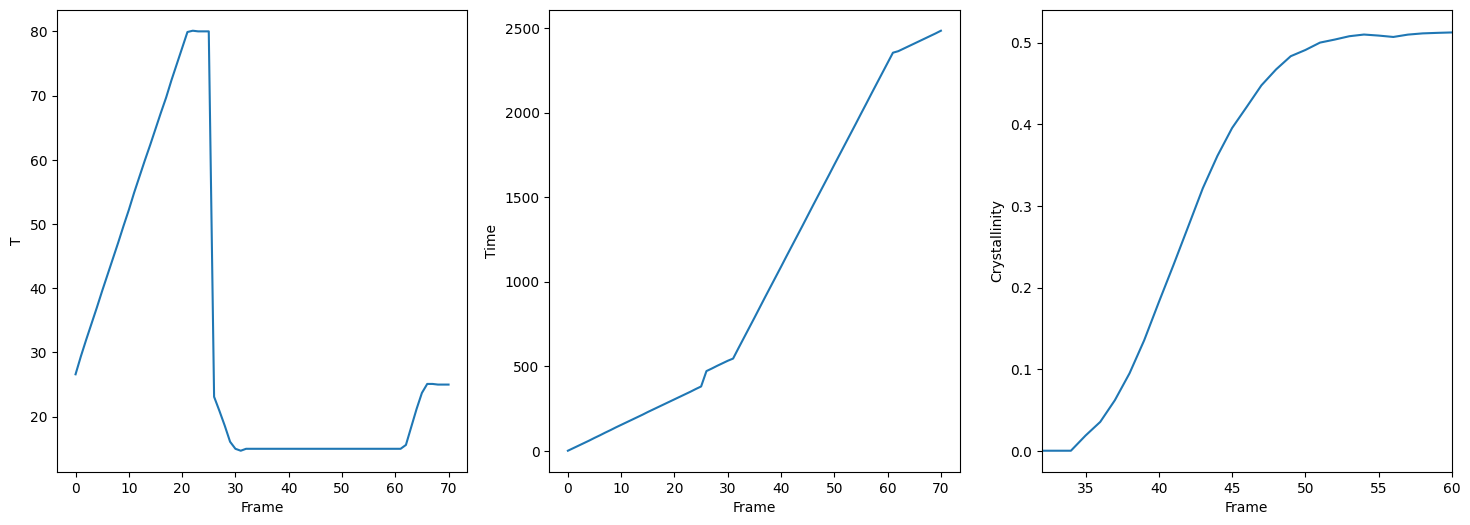

In [125]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_24_15C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
ax[2].set_xlim([32,60])
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 33: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0033.dat
Чтение WAXS файла 38: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0038.dat
Чтение WAXS файла 42: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0042.dat
Чтение WAXS файла 46: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0046.dat
Чтение WAXS файла 50: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0050.dat


(-0.1, 6.0)

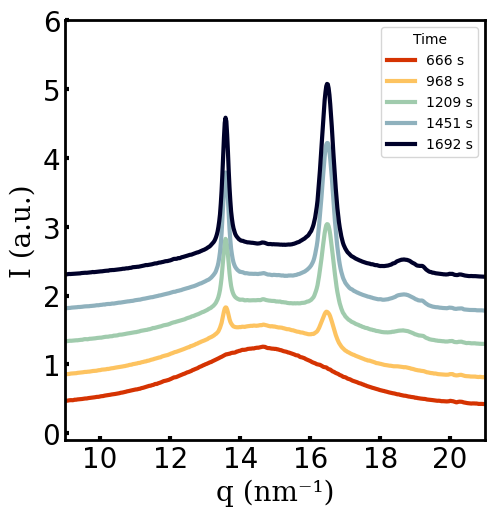

In [129]:
WAXS_plot(6,6)
Exp = Exp292_24_15C
lnwdth = 3
k = 0.5
times = [33,38,42,46,50]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_WAXS(times[0])
plt.plot(q, I/1000+0.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_WAXS(times[1])
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_WAXS(times[2])
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_WAXS(times[3])
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_WAXS(times[4])
plt.plot(q, I/1000+ k*4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(9, 21)
plt.ylim(-0.1, 6)

Чтение SAXS файла 33: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0033.dat
Чтение SAXS файла 38: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0038.dat
Чтение SAXS файла 42: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0042.dat
Чтение SAXS файла 46: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0046.dat
Чтение SAXS файла 50: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0050.dat


(0.0102, 8000.0)

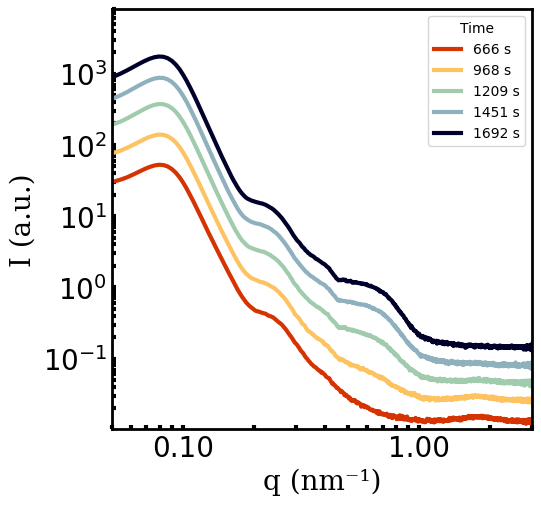

In [130]:
SAXS_plot(6,6)
Exp = Exp292_24_15C
lnwdth = 3
k = 1.8
times = [33,38,42,46,50]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_SAXS(times[0])
plt.plot(q, I/1.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(0.05, 3)
plt.ylim(1.02e-2, 8e3)

(15.0, 45.0)

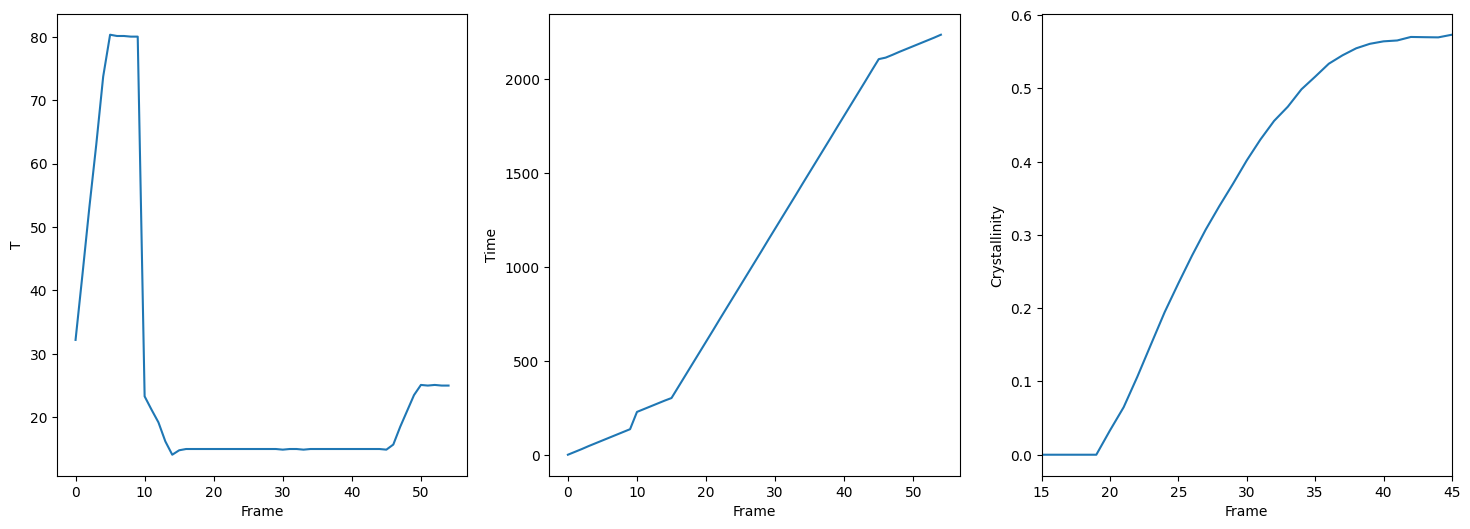

In [131]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info576_24_15C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
ax[2].set_xlim([15,45])
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 18: PEG_PNIPAM_576_24_Cryst_at_15C_bis_WAXS_0018.dat
Чтение WAXS файла 22: PEG_PNIPAM_576_24_Cryst_at_15C_bis_WAXS_0022.dat
Чтение WAXS файла 29: PEG_PNIPAM_576_24_Cryst_at_15C_bis_WAXS_0029.dat
Чтение WAXS файла 35: PEG_PNIPAM_576_24_Cryst_at_15C_bis_WAXS_0035.dat
Чтение WAXS файла 40: PEG_PNIPAM_576_24_Cryst_at_15C_bis_WAXS_0040.dat


(-0.1, 6.0)

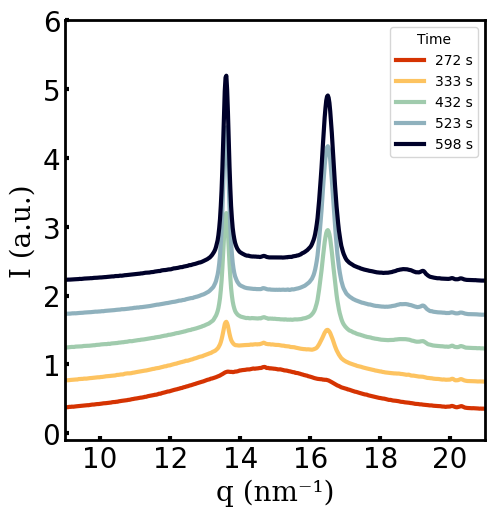

In [142]:
WAXS_plot(6,6)
Exp = Exp576_24_15C
lnwdth = 3
k = 0.5
times = [18,22,29,35,40]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_WAXS(times[0])
plt.plot(q, I/1000+0.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_WAXS(times[1])
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_WAXS(times[2])
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_WAXS(times[3])
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_WAXS(times[4])
plt.plot(q, I/1000+ k*4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(9, 21)
plt.ylim(-0.1, 6)

Чтение SAXS файла 18: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0018.dat
Чтение SAXS файла 22: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0022.dat
Чтение SAXS файла 29: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0029.dat
Чтение SAXS файла 35: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0035.dat
Чтение SAXS файла 40: PEG_PNIPAM_576_24_Cryst_at_15C_bis_SAXS_0040.dat


(0.0102, 8000.0)

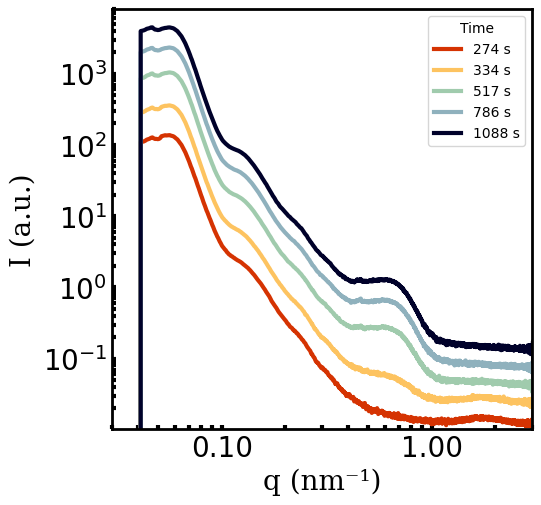

In [164]:
SAXS_plot(6,6)
Exp = Exp576_24_15C
lnwdth = 3
k = 1.8
times = [18,22,29,35,40]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_SAXS(times[0])
plt.plot(q, I/1.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(0.03, 3)
plt.ylim(1.02e-2, 8e3)

(55.0, 75.0)

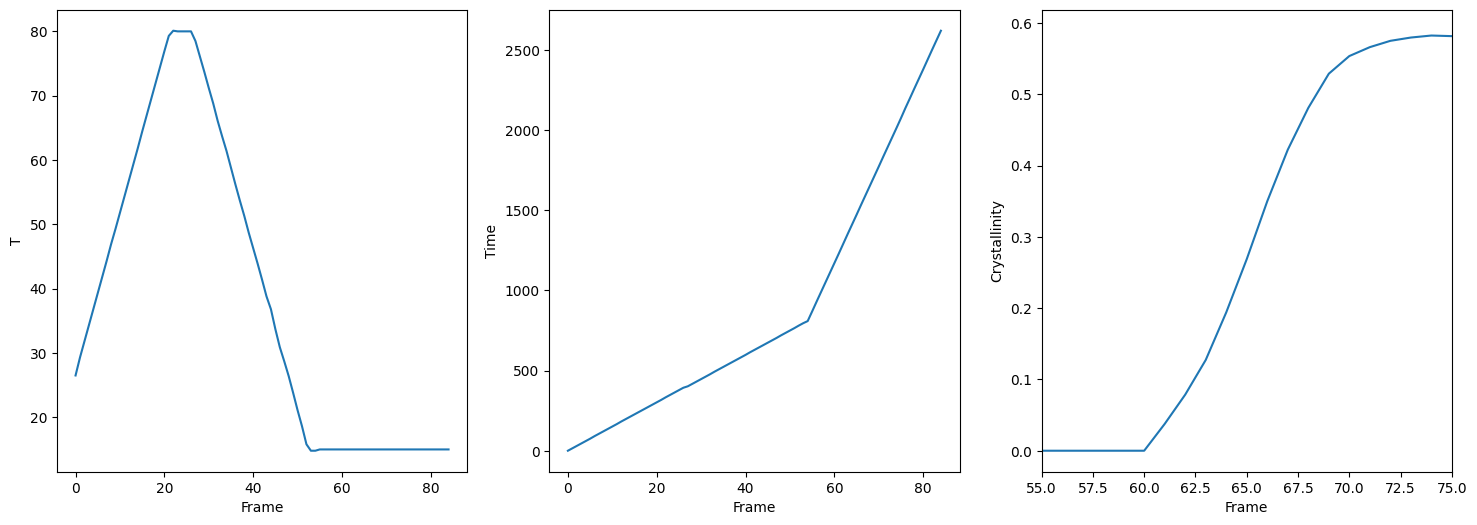

In [137]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info888_24_15C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
ax[2].set_xlim([55,75])
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 58: PEG_PNIPAM_888_24_Cryst_at_15C_WAXS_0058.dat
Чтение WAXS файла 62: PEG_PNIPAM_888_24_Cryst_at_15C_WAXS_0062.dat
Чтение WAXS файла 65: PEG_PNIPAM_888_24_Cryst_at_15C_WAXS_0065.dat
Чтение WAXS файла 68: PEG_PNIPAM_888_24_Cryst_at_15C_WAXS_0068.dat
Чтение WAXS файла 73: PEG_PNIPAM_888_24_Cryst_at_15C_WAXS_0073.dat


(-0.1, 6.0)

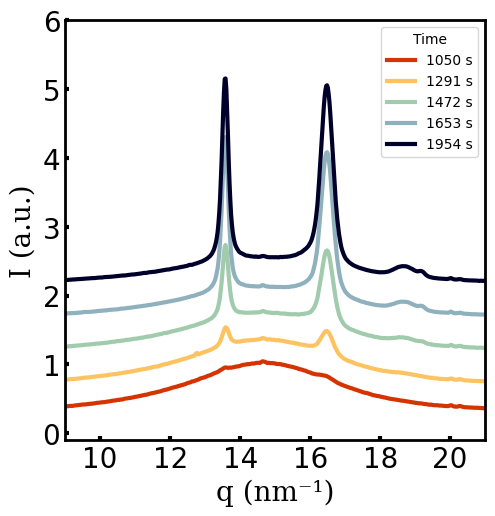

In [139]:
WAXS_plot(6,6)
Exp = Exp888_24_15C
lnwdth = 3
k = 0.5
times = [58,62,65,69,73]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_WAXS(times[0])
plt.plot(q, I/1000+0.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_WAXS(times[1])
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_WAXS(times[2])
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_WAXS(times[3])
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_WAXS(times[4])
plt.plot(q, I/1000+ k*4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(9, 21)
plt.ylim(-0.1, 6)

KeyError: 71

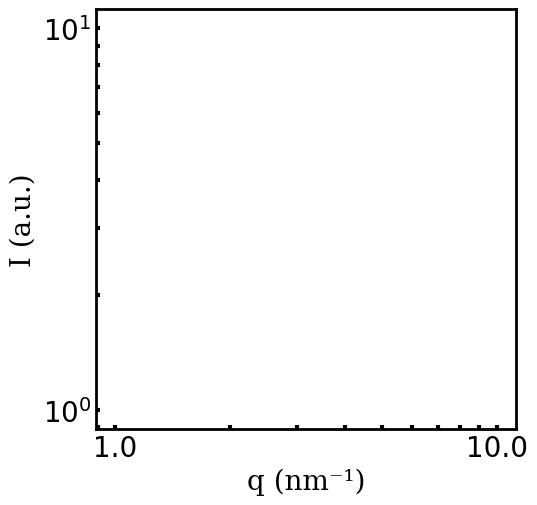

In [172]:
SAXS_plot(6,6)
Exp = Exp888_24_15C
lnwdth = 3
k = 1.8
times = [58,62,65,69,73]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_SAXS(times[0])
plt.plot(q, I/1.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(0.05, 3)
plt.ylim(1.02e-2, 8e3)

(30.0, 50.0)

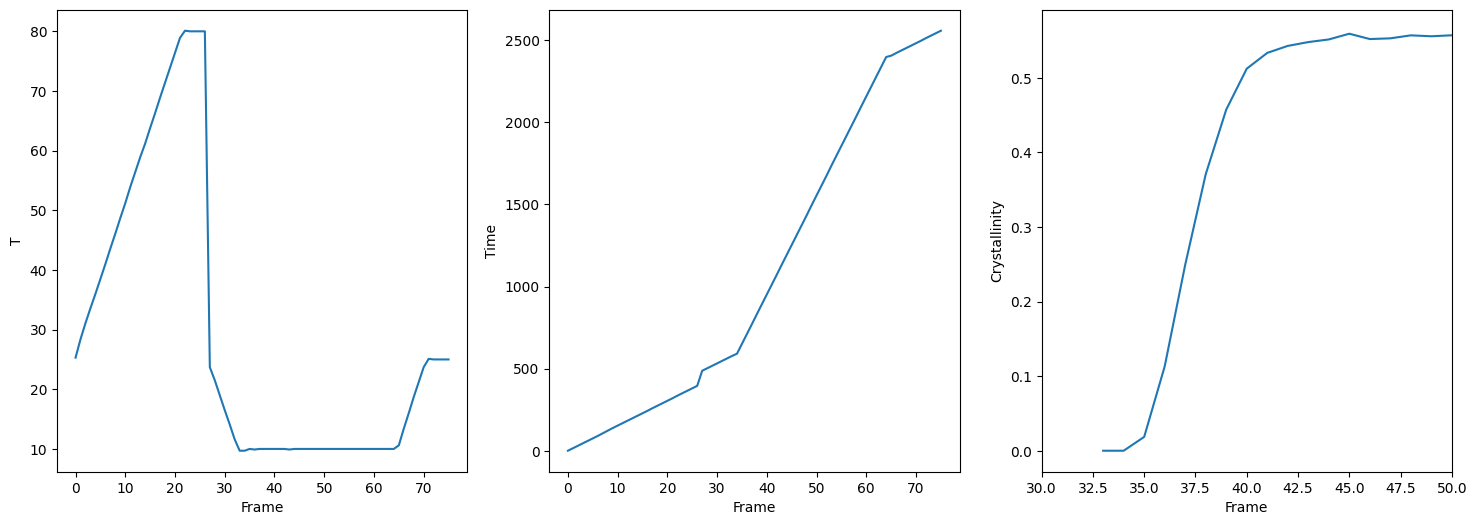

In [143]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_24_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
ax[2].set_xlim([30,50])
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 33: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0033.dat
Чтение WAXS файла 35: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0035.dat
Чтение WAXS файла 37: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0037.dat
Чтение WAXS файла 40: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0040.dat
Чтение WAXS файла 42: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0042.dat


(-0.1, 6.0)

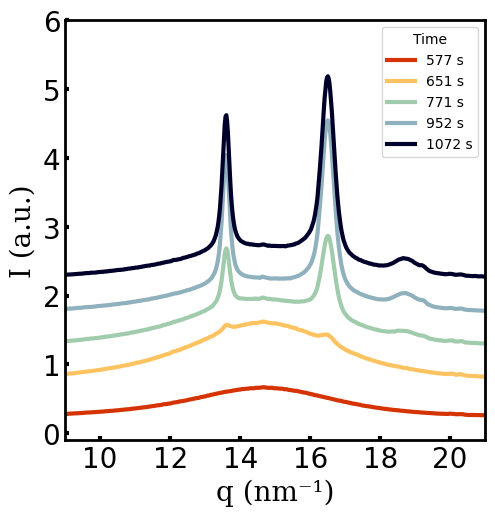

In [148]:
WAXS_plot(6,6)
Exp = Exp292_24_10C
lnwdth = 3
k = 0.5
times = [33,35,37,40,42]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_WAXS(times[0])
plt.plot(q, I/1000+0.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_WAXS(times[1])
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_WAXS(times[2])
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_WAXS(times[3])
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_WAXS(times[4])
plt.plot(q, I/1000+ k*4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(9, 21)
plt.ylim(-0.1, 6)

Чтение SAXS файла 33: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0033.dat
Чтение SAXS файла 35: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0035.dat
Чтение SAXS файла 37: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0037.dat
Чтение SAXS файла 40: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0040.dat
Чтение SAXS файла 42: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0042.dat


(0.0102, 8000.0)

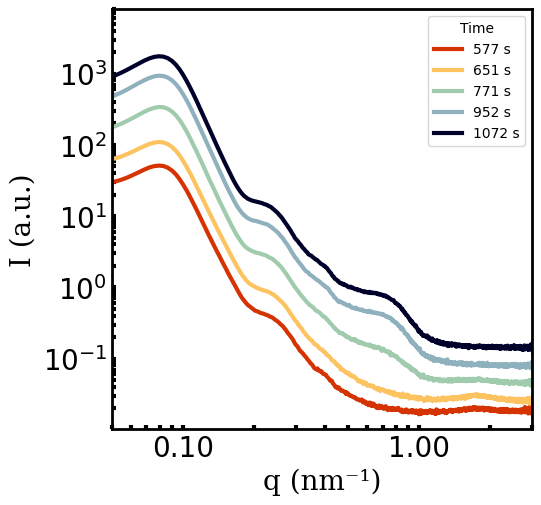

In [147]:
SAXS_plot(6,6)
Exp = Exp292_24_10C
lnwdth = 3
k = 1.8
times = [33,35,37,40,42]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_SAXS(times[0])
plt.plot(q, I/1.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(0.05, 3)
plt.ylim(1.02e-2, 8e3)

(30.0, 55.0)

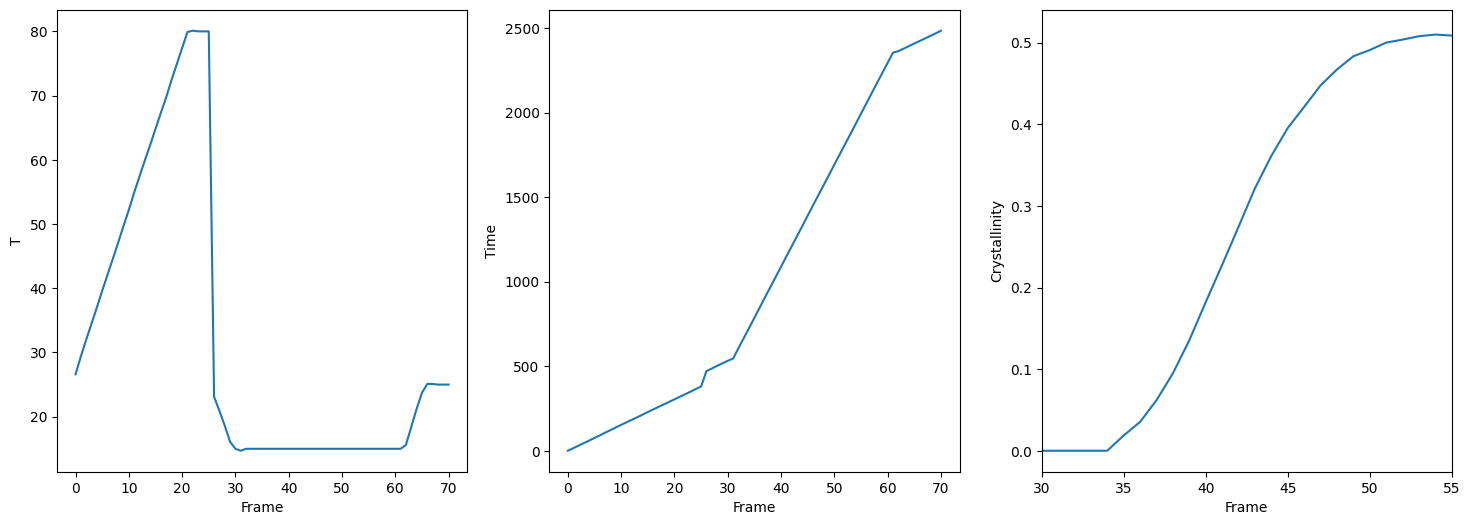

In [150]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_24_15C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
ax[2].set_xlim([30,55])
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 31: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0031.dat
Чтение WAXS файла 36: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0036.dat
Чтение WAXS файла 41: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0041.dat
Чтение WAXS файла 47: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0047.dat
Чтение WAXS файла 52: PEG_PNIPAM_292_24_Cryst_at_15C_WAXS_0052.dat


(-0.1, 6.0)

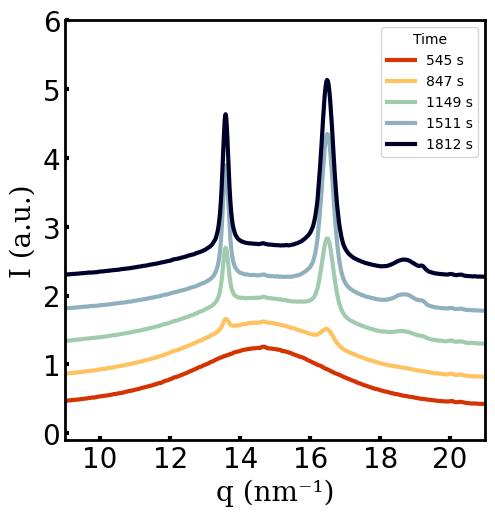

In [151]:
WAXS_plot(6,6)
Exp = Exp292_24_15C
lnwdth = 3
k = 0.5
times = [31,36,41,47,52]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_WAXS(times[0])
plt.plot(q, I/1000+0.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_WAXS(times[1])
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_WAXS(times[2])
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_WAXS(times[3])
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_WAXS(times[4])
plt.plot(q, I/1000+ k*4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(9, 21)
plt.ylim(-0.1, 6)

Чтение SAXS файла 31: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0031.dat
Чтение SAXS файла 36: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0036.dat
Чтение SAXS файла 41: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0041.dat
Чтение SAXS файла 47: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0047.dat
Чтение SAXS файла 52: PEG_PNIPAM_292_24_Cryst_at_15C_SAXS_0052.dat


(0.0102, 8000.0)

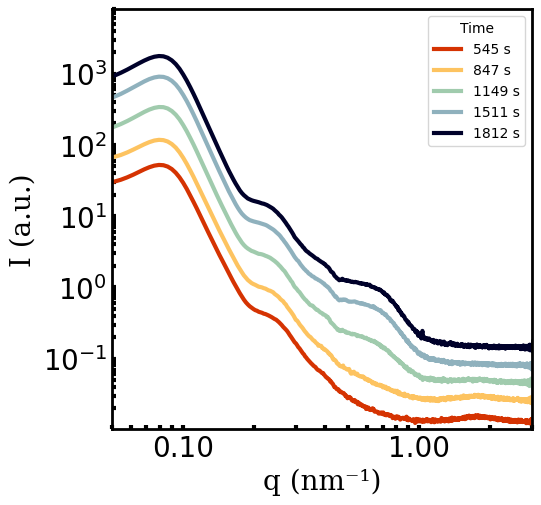

In [152]:
SAXS_plot(6,6)
Exp = Exp292_24_15C
lnwdth = 3
k = 1.8
times = [31,36,41,47,52]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_SAXS(times[0])
plt.plot(q, I/1.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(0.05, 3)
plt.ylim(1.02e-2, 8e3)

Text(0, 0.5, 'Crystallinity')

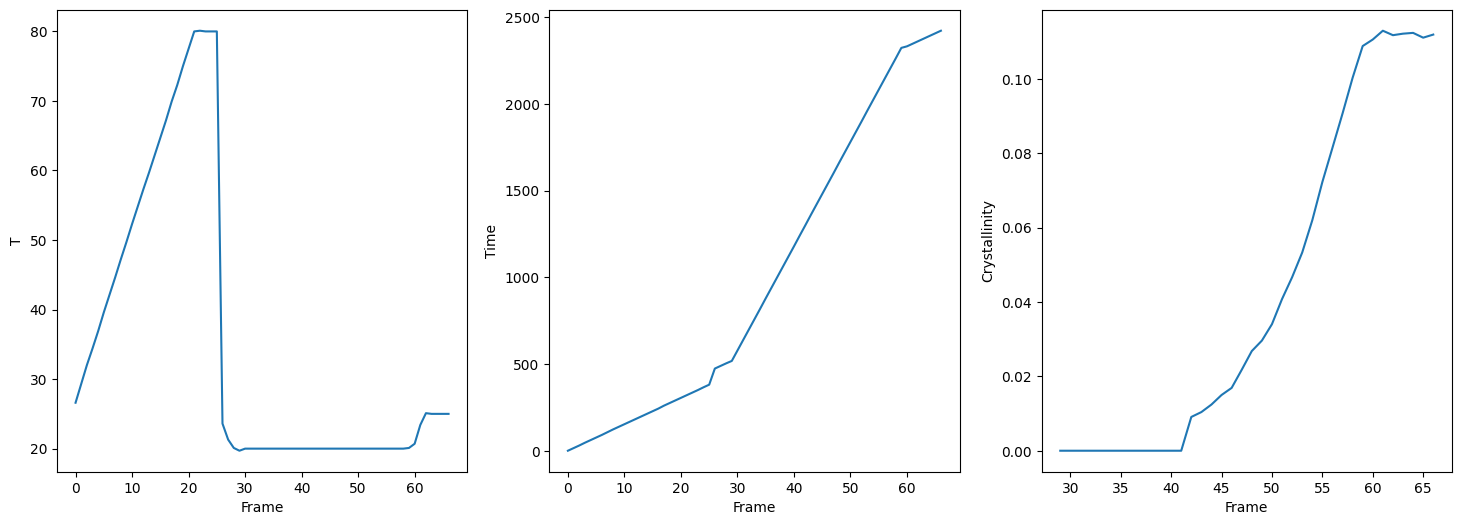

In [63]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_24_20C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 40: PEG_PNIPAM_292_24_Cryst_at_20C_WAXS_0040.dat
Чтение WAXS файла 45: PEG_PNIPAM_292_24_Cryst_at_20C_WAXS_0045.dat
Чтение WAXS файла 50: PEG_PNIPAM_292_24_Cryst_at_20C_WAXS_0050.dat
Чтение WAXS файла 55: PEG_PNIPAM_292_24_Cryst_at_20C_WAXS_0055.dat
Чтение WAXS файла 59: PEG_PNIPAM_292_24_Cryst_at_20C_WAXS_0059.dat


(-0.1, 6.0)

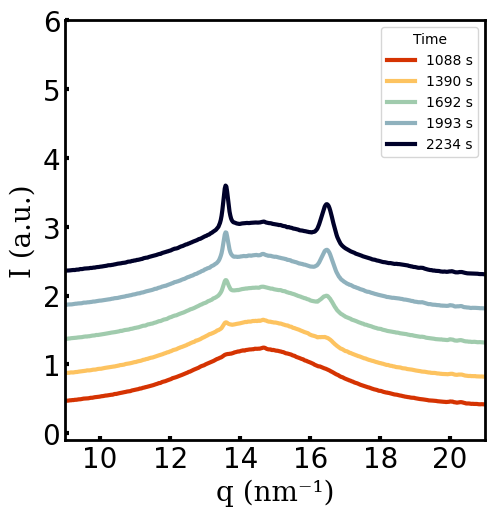

In [155]:
WAXS_plot(6,6)
Exp = Exp292_24_20C
lnwdth = 3
k = 0.5
times = [40,45,50,55,59]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_WAXS(times[0])
plt.plot(q, I/1000+0.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_WAXS(times[1])
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_WAXS(times[2])
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_WAXS(times[3])
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_WAXS(times[4])
plt.plot(q, I/1000+ k*4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(9, 21)
plt.ylim(-0.1, 6)

Чтение SAXS файла 40: PEG_PNIPAM_292_24_Cryst_at_20C_SAXS_0040.dat
Чтение SAXS файла 45: PEG_PNIPAM_292_24_Cryst_at_20C_SAXS_0045.dat
Чтение SAXS файла 50: PEG_PNIPAM_292_24_Cryst_at_20C_SAXS_0050.dat
Чтение SAXS файла 55: PEG_PNIPAM_292_24_Cryst_at_20C_SAXS_0055.dat
Чтение SAXS файла 59: PEG_PNIPAM_292_24_Cryst_at_20C_SAXS_0059.dat


(0.0102, 8000.0)

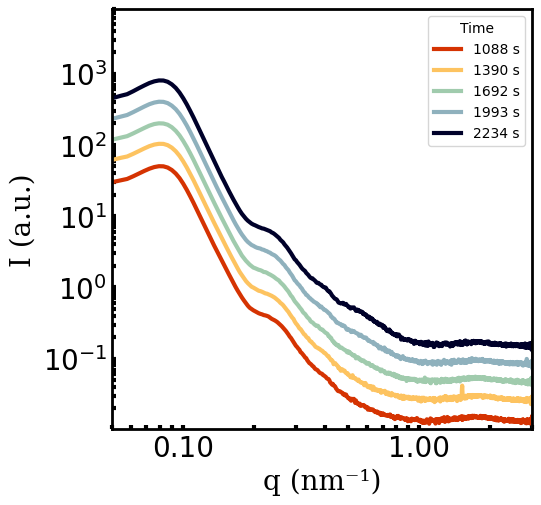

In [156]:
SAXS_plot(6,6)
Exp = Exp292_24_20C
lnwdth = 3
k = 1.8
times = [40,45,50,55,59]
t1 = Info['Time'][times[0]]
t2 = Info['Time'][times[1]]
t3 = Info['Time'][times[2]]
t4 = Info['Time'][times[3]]
t5 = Info['Time'][times[4]]

q, I = Exp.get_1d_SAXS(times[0])
plt.plot(q, I/1.1, linewidth=lnwdth, color='#D53302', label=f'{t1} s')

q, I = Exp.get_1d_SAXS(times[1])
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360', label=f'{t2} s')

q, I = Exp.get_1d_SAXS(times[2])
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD', label=f'{t3} s')

q, I = Exp.get_1d_SAXS(times[3])
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD', label=f'{t4} s')

q, I = Exp.get_1d_SAXS(times[4])
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A', label=f'{t5} s')

plt.legend(title='Time')

plt.xlim(0.05, 3)
plt.ylim(1.02e-2, 8e3)